# Ontario woodland caribou core habitat: 2015-2025

Updated reconstruction of Mackey et al. (2024) Figure 6 for the seven Ontario ranges
(**Berens, Brightsand, Churchill, Kesagami, Nipigon, Pagwachuan, Sydney**).

**What changed from the 2020-2024 version**

1. **Harvest is now the union of two sources.** The Ontario Analysis Ready inventory (ARI) covers only
   0.6-50.6% of these ranges and captured just 19.6% of the harvest visible in the national Landsat
   product (438,711 ha vs 1,608,680 ha; 93.8% of the difference falls where ARI has no polygon at all).
   Following the paper's own precedence rule, the national layer now gap-fills ARI: the ARI depletion
   year wins wherever an ARI harvest polygon exists, the national harvest year fills every other pixel.
2. **Harvest window widened to 1976**, matching the paper, instead of 1980.
3. **The 500 m buffer is applied once to the combined harvest mask** by exact Euclidean distance
   transform, rather than vector-buffering ARI alone.
4. **Core habitat area bug fixed.** The previous run counted NoData (255) pixels as core, inflating
   `core_habitat_ha` about six-fold (Berens 2020: 1,463,361 ha reported vs 220,159 ha actual).
5. **Natural disturbance now recovers after 40 years.** Fire and other natural depletions use a
   rolling `year - 40` window rather than a fixed 1980 start, matching the Environment Canada
   method whose risk thresholds this analysis applies. Harvest keeps a fixed 1976 start, since
   anthropogenic footprint does not recover under that method. At 2020 the rolling window spans
   1980-2020 and is identical to the previous behaviour, so the Table 4 comparison is unchanged;
   2025 sheds 284,373 ha of early-1980s fire (14.6% of all fire, and 39.8% of Brightsand's).
6. **Time range is now 2015-2025.**

Outputs go to `outputs_v2/` so the original 2020-2024 run stays intact for comparison.

## 0. Read this before interpreting the annual series

Three limits are structural to the available inputs and are **not** fixed by this notebook:

| Limit | Effect |
| --- | --- |
| ECCC anthropogenic + 40-year fire is a **fixed 2020 baseline**, with no year attribute in the file we hold | Every year 2015-2025 inherits the 2020 non-forest footprint, so 2015-2019 values **overstate** disturbance for those years. Only the harvest, fire and other-depletion components genuinely vary by year. The rolling 40-year recovery window below therefore applies only to the ARI component; ECCC's embedded fire stays frozen at its 1980-2020 span. |
| The national harvest raster ends at **2022**; ARI depletions run through **2024** | 2023-2024 gain new harvest from ARI only. 2025 has no new data in either source, so 2025 will equal 2024. |
| Potential habitat is the **static 2019** VLCE2 layer | Consistent with the paper's single-snapshot approach, but it is not a land-cover time series. |

The genuine year-on-year signal here is the growth of the harvest / fire / depletion footprint, not the
absolute disturbance level.

## 1. Environment and paths

Run with the `superenv` kernel. Inputs are read from `data/`; everything generated goes to
`outputs_v2/` and `data/interim/`.

In [1]:
from pathlib import Path
import warnings

import cv2
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import pyogrio
import rasterio
from rasterio.features import rasterize
from rasterio.mask import mask
from scipy import ndimage
from shapely.geometry import mapping

warnings.filterwarnings('ignore', category=UserWarning)
PROJECT_MARKER = Path('data') / 'Caribou_range_boundary' / 'Caribou_range_boundary.shp'
ROOT = next((c for c in [Path.cwd(), Path.cwd().parent] if (c / PROJECT_MARKER).exists()), Path.cwd())
DATA = ROOT / 'data'
RAW = DATA / 'raw'
INTERIM = DATA / 'interim'
OUT = ROOT / 'outputs_v3'
LEGACY_POTENTIAL = ROOT / 'outputs' / '01_potential_habitat'
for folder in [INTERIM / 'ari_events', OUT / '00_qc', OUT / '01_potential_habitat',
               OUT / '02_disturbance', OUT / '03_undisturbed_habitat', OUT / '04_statistics',
               OUT / '05_mspa', OUT / 'figures']:
    folder.mkdir(parents=True, exist_ok=True)

RANGES = DATA / 'Caribou_range_boundary' / 'Caribou_range_boundary.shp'
ARI = DATA / 'ontario_ar_forest_only' / 'ontario_ar_master_dataset_forestonly.shp'
ARI_GDB = (DATA / 'ARI_AnalysisReadyInventory2025' / 'ARI_AnalysisReadyInventory2025' / 'ARI_wFU.gdb')
BOUNDARY_LAYER = '_FMU_FN_PARK_Boundary_simp2m'
LANDCOVER_ZIP = RAW / 'landcover_2019' / 'CA_forest_VLCE2_2019.zip'
HARVEST_ZIP = RAW / 'national_harvest' / 'CA_Forest_Harvest_1985-2022.zip'
ECCC_DIR = RAW / 'disturbance_2020'

def vsizip(zip_path, member):
    return '/vsizip/' + str(zip_path.resolve()).replace('\\', '/') + '/' + member

LANDCOVER = vsizip(LANDCOVER_ZIP, 'CA_forest_VLCE2_2019.tif')
NATIONAL_HARVEST = vsizip(HARVEST_ZIP, 'CA_Forest_Harvest_1985-2022.tif')

TARGET_YEARS = list(range(2015, 2026))
HARVEST_START = 1976          # paper: logging from ~1976. Anthropogenic footprint does not
                              # recover under the ECCC method, so this stays a fixed start.
FIRE_WINDOW_YEARS = 40        # ECCC: natural disturbance counts for the past forty years, so
                              # fire older than this is treated as recovered. Rolling, not fixed:
                              # at 2020 it spans 1980-2020 and is identical to the paper's
                              # "fires since 1980", leaving the Table 4 comparison unchanged.
                              # Set to None to revert to a fixed FIRE_START.
FIRE_START = 1980             # used only when FIRE_WINDOW_YEARS is None
BUFFER_M = 500                # paper / ECCC: anthropogenic disturbance buffered 500 m
RES_M = 30
PIXEL_HA = 0.09
HABITAT_CODES = {81: 'Treed wetland', 210: 'Coniferous'}
OTHER_DEPTYPES = ['BLOWDOWN', 'DROUGHT', 'UNKNOWN']   # insects excluded, as in the paper
PAPER_RANGES = ['Berens', 'Brightsand', 'Churchill', 'Kesagami', 'Nipigon', 'Pagwachuan', 'Sydney']
NODATA = 255

# Mackey et al. Table 4 values for these seven ranges, for the comparison at the end.
PAPER_TABLE4 = pd.DataFrame([
    ('Berens', 1612106, 369895, 46.4), ('Brightsand', 1525297, 241067, 65.6),
    ('Churchill', 2035815, 427948, 49.0), ('Kesagami', 3373204, 1042716, 53.5),
    ('Nipigon', 2928933, 243926, 74.4), ('Pagwachuan', 2165773, 408060, 67.8),
    ('Sydney', 578902, 69528, 50.0)],
    columns=['RANGE_NAME', 'paper_range_ha', 'paper_habitat_ha', 'paper_pct_disturbed'])

assert all(p.exists() for p in [RANGES, ARI, LANDCOVER_ZIP, HARVEST_ZIP])
print('Project root  :', ROOT)
print('Output root   :', OUT)
print('Target years  :', TARGET_YEARS)
print('Harvest window : %d -> target year (no recovery)' % HARVEST_START)
if FIRE_WINDOW_YEARS:
    print('Natural window : rolling %d years, e.g. %d-%d at 2015 and %d-%d at 2025'
          % (FIRE_WINDOW_YEARS, 2015 - FIRE_WINDOW_YEARS, 2015, 2025 - FIRE_WINDOW_YEARS, 2025))
else:
    print('Natural window : %d -> target year (fixed)' % FIRE_START)

Project root  : f:\forest_data_curation\caribou_habitat\Reproduce_brenden
Output root   : f:\forest_data_curation\caribou_habitat\Reproduce_brenden\outputs_v3
Target years  : [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Harvest window : 1976 -> target year (no recovery)
Natural window : rolling 40 years, e.g. 1975-2015 at 2015 and 1985-2025 at 2025


## 2. The seven study ranges

Source ranges are NAD83 geographic; all analysis is Canada Atlas Lambert (EPSG:3978), the CRS of the
VLCE2, national harvest and ECCC inputs.

,RANGE_NAME,RANGE_TYPE
0,Berens,Continuous
1,Brightsand,Continuous
2,Churchill,Continuous
3,Kesagami,Continuous
4,Nipigon,Continuous
5,Pagwachuan,Continuous
6,Sydney,Continuous


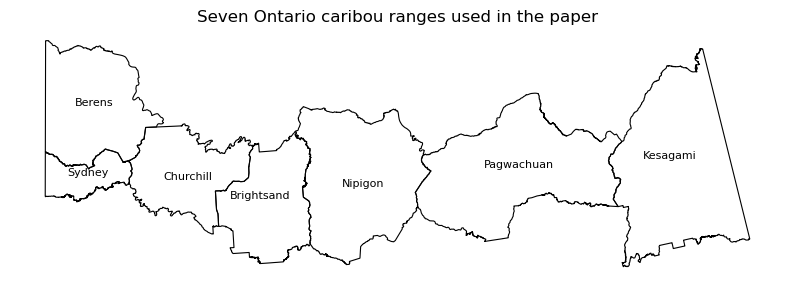

c:\Users\mrahaman3\.conda\envs\superenv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


Area of Undertaking (TYPE=MU): 44.12 M ha across 39 units


,RANGE_NAME,range_ha,range_in_AoU_ha,paper_range_ha,AoU_over_paper
0,Berens,2748716.81,1582195.07,1612106,0.98
1,Brightsand,2202669.19,1513389.79,1525297,0.99
2,Churchill,2110258.94,2010004.44,2035815,0.99
3,Kesagami,4729769.76,3360248.64,3373204,1.00
4,Nipigon,3826949.46,2897147.28,2928933,0.99
5,Pagwachuan,4484454.62,2150930.29,2165773,0.99
6,Sydney,741815.09,571548.80,578902,0.99


In [2]:
ranges_all = gpd.read_file(RANGES)
ranges = ranges_all.loc[ranges_all['RANGE_NAME'].isin(PAPER_RANGES)].copy().to_crs(3978)
ranges = ranges.set_index('RANGE_NAME').loc[PAPER_RANGES].reset_index()
assert len(ranges) == 7 and ranges.geometry.is_valid.all()
display(ranges[['RANGE_NAME', 'RANGE_TYPE']])

fig, ax = plt.subplots(figsize=(10, 8))
ranges.boundary.plot(ax=ax, color='black', linewidth=0.8)
for _, row in ranges.iterrows():
    p = row.geometry.representative_point()
    ax.annotate(row.RANGE_NAME, (p.x, p.y), fontsize=8, ha='center')
ax.set_title('Seven Ontario caribou ranges used in the paper')
ax.set_axis_off()
fig.savefig(OUT / '00_qc' / '01_paper_ranges.png', dpi=220, bbox_inches='tight')
plt.show()

# Study area: the Ontario Area of Undertaking (managed units) from the ARI boundary layer.
# Range∩MU reproduces the paper's "Local Population Range Area" to within 2% on all seven
# ranges (total 14,085,464 ha vs the paper's 14,220,030 ha), which identifies it as the
# paper's analysis boundary.
boundary = gpd.read_file(ARI_GDB, layer=BOUNDARY_LAYER).to_crs(3978)
if not boundary.geometry.is_valid.all():
    boundary.geometry = boundary.geometry.make_valid()
study_area = boundary.loc[boundary.TYPE == 'MU']
STUDY_AREA = study_area.geometry.union_all()
print('Area of Undertaking (TYPE=MU): %.2f M ha across %d units' % (STUDY_AREA.area / 1e10, len(study_area)))
check = pd.DataFrame([{'RANGE_NAME': r.RANGE_NAME,
                       'range_ha': r.geometry.area / 1e4,
                       'range_in_AoU_ha': r.geometry.intersection(STUDY_AREA).area / 1e4}
                      for r in ranges.itertuples()]).merge(PAPER_TABLE4[['RANGE_NAME', 'paper_range_ha']],
                                                           on='RANGE_NAME')
check['AoU_over_paper'] = check.range_in_AoU_ha / check.paper_range_ha
display(check.round(2))

## 3. Input inspection and data availability

Confirms the VLCE2 and national harvest grids are identical (so no resampling is needed), and shows
where each harvest source actually has data across the target years.

In [3]:
for label, path in {'landcover_2019': LANDCOVER, 'national_harvest': NATIONAL_HARVEST}.items():
    with rasterio.open(path) as ds:
        print('%-16s CRS=%s res=%s size=%dx%d origin=(%.3f, %.3f) dtype=%s'
              % (label, ds.crs, ds.res, ds.width, ds.height, ds.transform.c, ds.transform.f, ds.dtypes[0]))

ari_summary = pyogrio.read_dataframe(ARI, columns=['YRDEP', 'DEPTYPE', 'Ha'], read_geometry=False)
ari_summary['YRDEP'] = pd.to_numeric(ari_summary['YRDEP'], errors='coerce')
print()
print('ARI depletion types, province-wide (all years):')
display(ari_summary.groupby('DEPTYPE', dropna=False)
        .agg(features=('YRDEP', 'size'), hectares=('Ha', 'sum')).sort_values('hectares', ascending=False))
print('ARI hectares by target year, province-wide:')
display(ari_summary.loc[ari_summary.YRDEP.between(TARGET_YEARS[0], TARGET_YEARS[-1])]
        .pivot_table(index='YRDEP', columns='DEPTYPE', values='Ha', aggfunc='sum', fill_value=0).round(0))

landcover_2019   CRS=EPSG:3978 res=(30.0, 30.0) size=193936x128340 origin=(-2660910.524, 2998848.110) dtype=uint8
national_harvest CRS=EPSG:3978 res=(30.0, 30.0) size=193936x128340 origin=(-2660910.524, 2998848.110) dtype=uint16

ARI depletion types, province-wide (all years):


,features,hectares
DEPTYPE,,
UNKNOWN,1057817,1.047930e+07
HARVEST,400042,2.321890e+06
FIRE,192230,1.956093e+06
BLOWDOWN,4990,4.208332e+04
INSECTS,326,4.552390e+03
SNOW,226,2.853928e+03
FLOOD,67,4.309160e+02
DISEASE,24,2.071870e+02
DROUGHT,3,3.723400e+01


ARI hectares by target year, province-wide:


DEPTYPE,BLOWDOWN,DROUGHT,FIRE,FLOOD,HARVEST,UNKNOWN
YRDEP,,,,,,
2015,4.0,0.0,2278.0,3.0,37346.0,73.0
2016,0.0,0.0,41535.0,0.0,44653.0,0.0
2017,15.0,0.0,5528.0,0.0,40942.0,29.0
2018,0.0,0.0,72314.0,0.0,58937.0,3016.0
2019,2681.0,0.0,92827.0,0.0,33707.0,0.0
2020,24.0,0.0,975.0,0.0,36151.0,0.0
2021,338.0,0.0,535347.0,0.0,34235.0,1063.0
2022,537.0,0.0,374.0,0.0,35336.0,0.0
2023,656.0,6.0,81373.0,0.0,33486.0,14.0


## 4. Helper functions

`build_range_layers` implements the gap-fill precedence rule: the ARI depletion year is used wherever
an ARI harvest polygon exists, and the national Landsat harvest year fills every remaining pixel.
`buffer_metres` applies one exact Euclidean 500 m buffer to the combined harvest mask.

In [4]:
def safe_name(name):
    return name.lower().replace(' ', '_')

def write_raster(path, array, profile, nodata=NODATA):
    profile = profile.copy()
    profile.update(driver='GTiff', count=1, dtype='uint8', nodata=nodata, compress='LZW')
    with rasterio.open(path, 'w', **profile) as dst:
        dst.write(array.astype('uint8'), 1)

def buffer_metres(mask_bool, metres=BUFFER_M, res=RES_M):
    """Exact Euclidean buffer of a boolean mask, in metres."""
    if not mask_bool.any():
        return mask_bool
    distance_px = cv2.distanceTransform((~mask_bool).astype('uint8'), cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
    return (distance_px * res) <= metres

def rasterize_years(geometries, years, profile):
    """Rasterize polygons carrying their year as the pixel value (0 = no polygon).

    int16 keeps the per-range working set small enough to hold in memory.
    """
    shapes = [(g, int(y)) for g, y in zip(geometries, years)
              if g is not None and not g.is_empty and 1800 < y < 2100]
    if not shapes:
        return np.zeros((profile['height'], profile['width']), dtype='int16')
    return rasterize(shapes, out_shape=(profile['height'], profile['width']),
                     transform=profile['transform'], fill=0, dtype='int16')

def rasterize_flat(geometries, profile):
    shapes = [(g, 1) for g in geometries if g is not None and not g.is_empty]
    if not shapes:
        return np.zeros((profile['height'], profile['width']), dtype='uint8')
    return rasterize(shapes, out_shape=(profile['height'], profile['width']),
                     transform=profile['transform'], fill=0, dtype='uint8')

def core_size_classes(undisturbed_bool, valid_mask):
    """MSPA-style core extraction.

    Returns (class raster, patch count, core mask). The class raster is
    0 = not core, 1-19 = patch size class, 255 = NoData outside the range. Callers
    count area from the core mask, so NoData can no longer be counted as core --
    the bug present in the previous version.
    """
    structure = np.ones((3, 3), dtype=bool)
    core = ndimage.binary_erosion(undisturbed_bool, structure=structure, border_value=0)
    labels, count = ndimage.label(core, structure=structure)
    areas = np.bincount(labels.ravel()) * PIXEL_HA
    bins = np.array([0, .25, .5, 1, 2, 3, 4, 5, 10, 25, 50, 100, 250, 500,
                     1000, 10000, 50000, 250000, 500000, np.inf])
    classes = np.digitize(areas, bins, right=False) - 1
    out = (classes[labels].astype('uint8') + 1)
    out[~core] = 0
    out[~valid_mask] = NODATA
    return out, int(count), (core & valid_mask)

def plot_mask(path, title, out_png, cmap, vmin=0, vmax=1, show=True):
    with rasterio.open(path) as ds:
        arr = ds.read(1, masked=True)
    fig, ax = plt.subplots(figsize=(8, 7))
    image = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(image, ax=ax, shrink=0.7)
    fig.savefig(out_png, dpi=150, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)

ECCC_FILES = {
    'Berens': 'eccc_2020_total_disturbance_02_Berens.geojson',
    'Brightsand': 'eccc_2020_total_disturbance_04_Brightsand.geojson',
    'Churchill': 'eccc_2020_total_disturbance_09_Churchill.geojson',
    'Kesagami': 'eccc_2020_total_disturbance_14_Kesagami.geojson',
    'Nipigon': 'eccc_2020_total_disturbance_26_Nipigon.geojson',
    'Pagwachuan': 'eccc_2020_total_disturbance_32_Pagwachuan.geojson',
    'Sydney': 'eccc_2020_total_disturbance_45_Sydney.geojson',
}

def load_ari_events(range_row):
    """Depletion polygons for one range.

    Prefers the cache built from the full ARI geodatabase (39 FMU + 8 Far North + 7 Park
    + 2 Islands layers, covering 86-100% of each range). Falls back to the cache built
    from ontario_ar_master_dataset_forestonly.shp, which covers only 0.6-50.6%.
    """
    key = safe_name(range_row.RANGE_NAME)
    gdb_cache = INTERIM / 'ari_events_gdb' / (key + '_ari_events.gpkg')
    if gdb_cache.exists():
        events = gpd.read_file(gdb_cache)
        events['YRDEP'] = pd.to_numeric(events['YRDEP'], errors='coerce')
        return events
    cache = INTERIM / 'ari_events' / (key + '_ari_events.gpkg')
    if cache.exists():
        events = gpd.read_file(cache)
    else:
        range_ari = gpd.GeoDataFrame([range_row], crs=3978).to_crs(3161)
        fields = ['ARI_ID', 'POLYTYPE', 'YRDEP', 'DEPTYPE', 'YRORG', 'AGE', 'Ha']
        events = pyogrio.read_dataframe(ARI, columns=fields, bbox=tuple(range_ari.total_bounds))
        events = events.loc[events.POLYTYPE.eq('FOR')].to_crs(3978)
        events = gpd.clip(events, range_row.geometry)
        events.to_file(cache, driver='GPKG')
    events['YRDEP'] = pd.to_numeric(events['YRDEP'], errors='coerce')
    return events

## 5. Potential habitat, 2019

VLCE2 class 81 (treed wetland) and 210 (coniferous) inside each range. This layer is static and
identical to the previous run, so the existing rasters are reused where present.

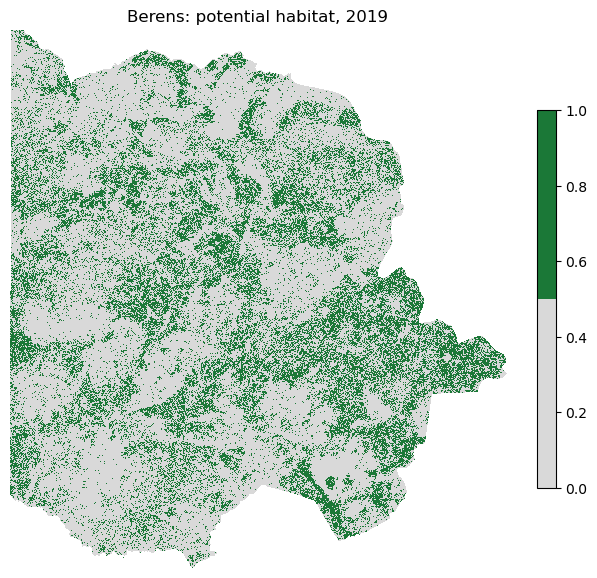

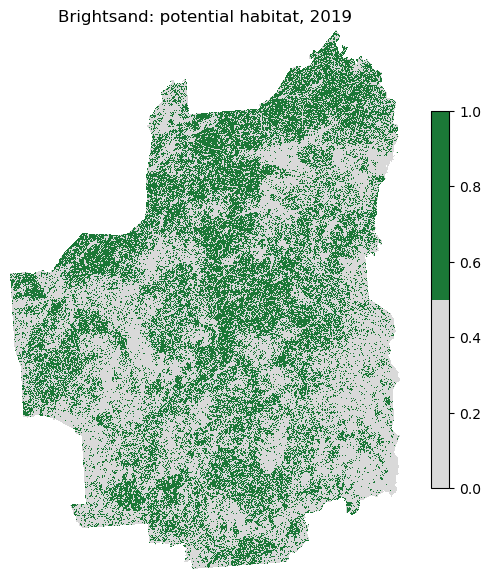

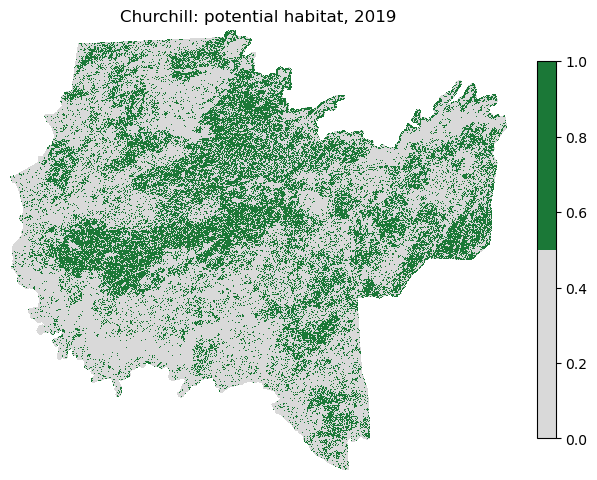

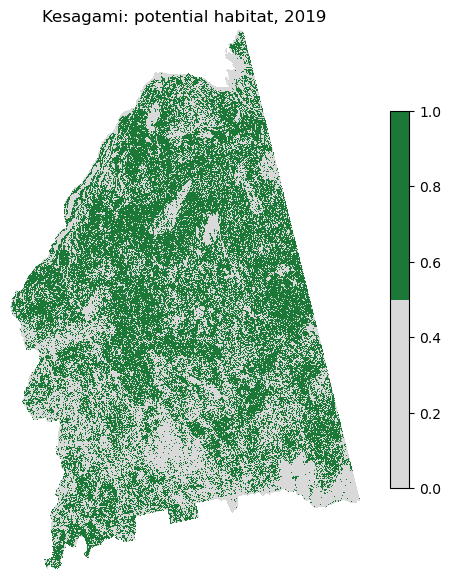

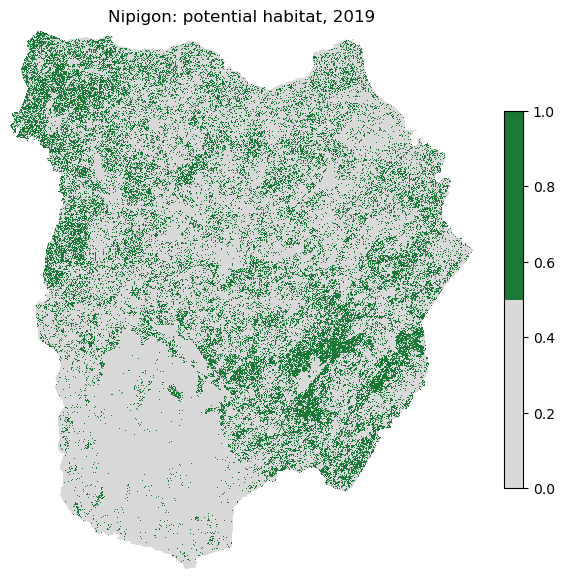

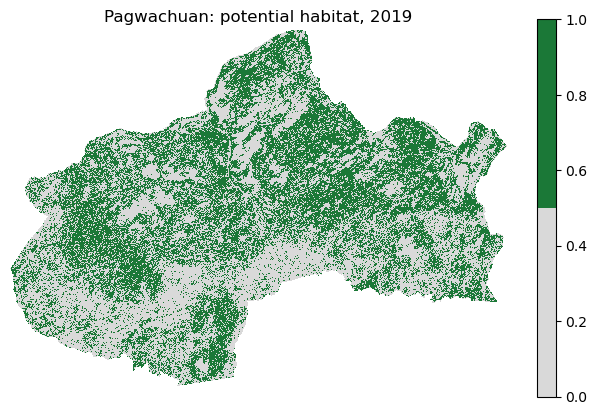

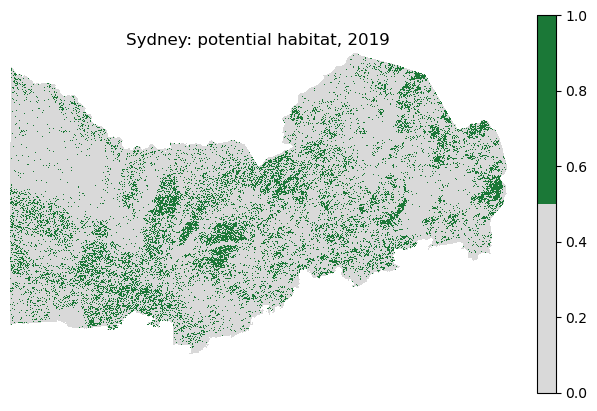

,RANGE_NAME,potential_habitat_ha_2019
0,Berens,767673.72
1,Brightsand,913811.04
2,Churchill,738957.87
3,Kesagami,2727673.11
4,Nipigon,979509.96
5,Pagwachuan,2115511.47
6,Sydney,138148.20


In [5]:
potential_paths = {}
for _, row in ranges.iterrows():
    key = safe_name(row.RANGE_NAME)
    tif = OUT / '01_potential_habitat' / (key + '_potential_habitat_2019.tif')
    if not tif.exists():
        legacy = LEGACY_POTENTIAL / (key + '_potential_habitat_2019.tif')
        if legacy.exists():
            with rasterio.open(legacy) as ds:
                write_raster(tif, ds.read(1), ds.profile)
        else:
            with rasterio.open(LANDCOVER) as src:
                clipped, transform = mask(src, [mapping(row.geometry)], crop=True, filled=True, nodata=NODATA)
                landcover = clipped[0]
                habitat = np.where(np.isin(landcover, list(HABITAT_CODES)), 1, 0).astype('uint8')
                habitat[landcover == NODATA] = NODATA
                profile = src.profile.copy()
                profile.update(height=habitat.shape[0], width=habitat.shape[1], transform=transform)
            write_raster(tif, habitat, profile)
    potential_paths[row.RANGE_NAME] = tif
    plot_mask(tif, row.RANGE_NAME + ': potential habitat, 2019',
              OUT / 'figures' / (key + '_01_potential_habitat_2019.png'),
              ListedColormap(['#d9d9d9', '#1b7837']))

potential_stats = []
for name, tif in potential_paths.items():
    with rasterio.open(tif) as ds:
        a = ds.read(1)
    potential_stats.append({'RANGE_NAME': name, 'potential_habitat_ha_2019': (a == 1).sum() * PIXEL_HA})
potential_stats = pd.DataFrame(potential_stats)
potential_stats.to_csv(OUT / '04_statistics' / 'potential_habitat_2019_by_range.csv', index=False)
display(potential_stats)

## 6. Per-range source layers

Built once per range, then thresholded for each target year. This is where the ARI / national harvest
union happens. The table reports how much harvest each source contributes and how much the national
layer adds on top of ARI.

In [6]:
def build_range_layers(range_row):
    name = range_row.RANGE_NAME
    with rasterio.open(potential_paths[name]) as ds:
        potential = ds.read(1)
        profile = ds.profile.copy()
    valid = potential != NODATA

    events = load_ari_events(range_row)
    harvest_ari = events.loc[events.DEPTYPE.eq('HARVEST')]
    fire_ari = events.loc[events.DEPTYPE.eq('FIRE')]
    other_ari = events.loc[events.DEPTYPE.isin(OTHER_DEPTYPES)]

    ari_year = rasterize_years(harvest_ari.geometry, harvest_ari.YRDEP.values, profile)
    fire_year = rasterize_years(fire_ari.geometry, fire_ari.YRDEP.values, profile)
    other_year = rasterize_years(other_ari.geometry, other_ari.YRDEP.values, profile)

    with rasterio.open(NATIONAL_HARVEST) as src:
        clipped, transform = mask(src, [mapping(range_row.geometry)], crop=True, filled=True, nodata=0)
    national_year = clipped[0].astype('int16')
    assert national_year.shape == potential.shape, 'national harvest grid is not aligned'
    assert abs(transform.c - profile['transform'].c) < 1e-6

    # Gap-fill precedence: ARI year wins where ARI mapped a harvest, national fills the rest.
    harvest_year = np.where(ari_year > 0, ari_year, national_year).astype('int16')

    eccc = gpd.read_file(ECCC_DIR / ECCC_FILES[name]).to_crs(3978)
    eccc_mask = rasterize_flat(gpd.clip(eccc, range_row.geometry).geometry, profile).astype(bool)

    # Paper's analysis boundary: range within the Area of Undertaking.
    study = rasterize_flat([STUDY_AREA.intersection(range_row.geometry)], profile).astype(bool) & valid

    def in_window(arr):
        return (arr >= HARVEST_START) & (arr <= TARGET_YEARS[-1]) & valid

    footprint = rasterize_flat(events.geometry, profile).astype(bool) & valid
    contribution = {
        'RANGE_NAME': name,
        'range_ha': valid.sum() * PIXEL_HA,
        'study_area_ha': study.sum() * PIXEL_HA,
        'ari_harvest_ha': in_window(ari_year).sum() * PIXEL_HA,
        'national_harvest_ha': in_window(national_year).sum() * PIXEL_HA,
        'union_harvest_ha': in_window(harvest_year).sum() * PIXEL_HA,
        'added_by_national_ha': (in_window(national_year) & ~in_window(ari_year)).sum() * PIXEL_HA,
        'ari_footprint_pct': 100 * footprint.sum() / valid.sum(),
    }
    layers = dict(potential=potential, profile=profile, valid=valid, study=study,
                  harvest_year=harvest_year, fire_year=fire_year, other_year=other_year,
                  eccc=eccc_mask)
    return layers, contribution

print('build_range_layers ready. Layers are built one range at a time in the next cell so that only')
print('one range is resident in memory (all seven at once would need roughly 3 GB).')

build_range_layers ready. Layers are built one range at a time in the next cell so that only
one range is resident in memory (all seven at once would need roughly 3 GB).


## 7. Annual disturbance, undisturbed habitat and core habitat

For each year: cumulative harvest (ARI union national, 1976 -> year) buffered 500 m, union ARI fire
(1980 -> year, unbuffered), union other ARI depletions, union the fixed ECCC 2020 footprint.
Maps are written for every year; the notebook displays the first and last year inline.

Building layers for Berens
  processing Berens, 2015


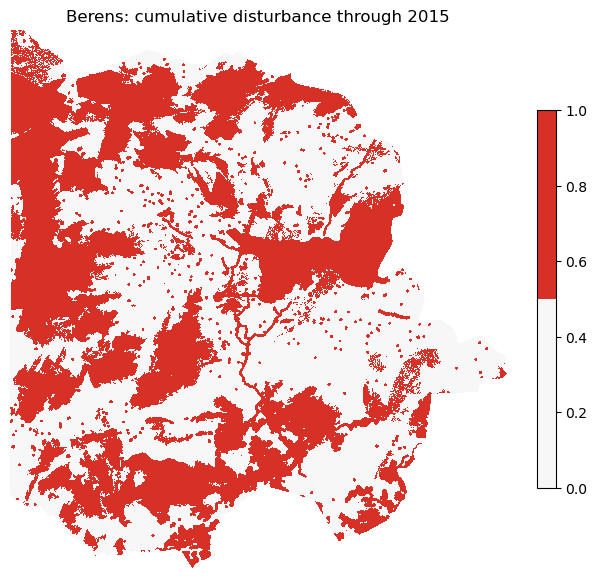

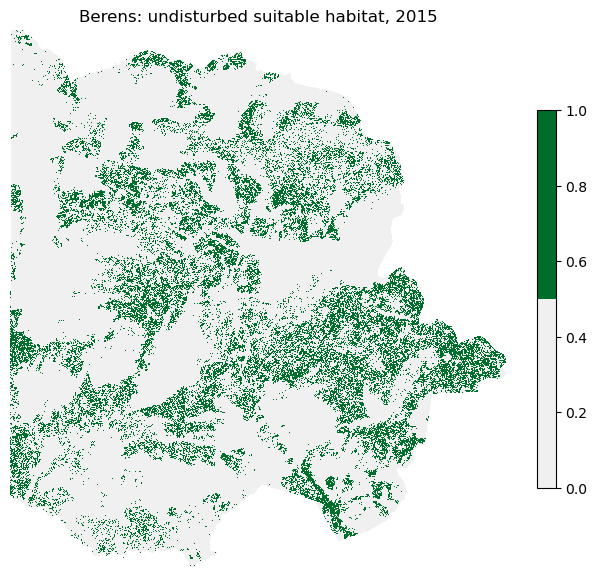

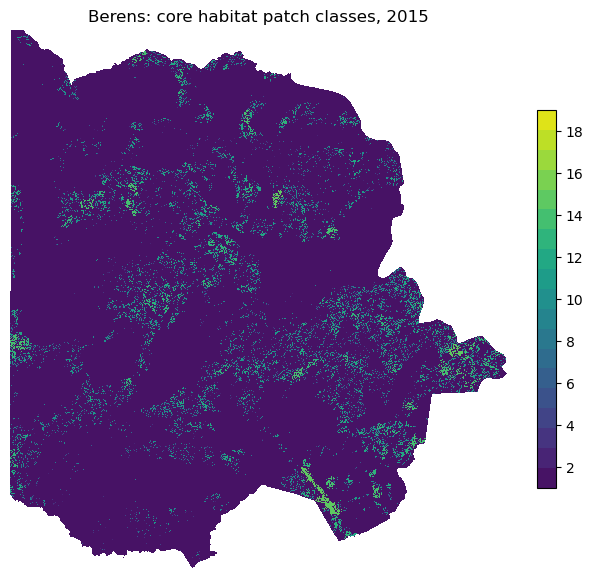

  processing Berens, 2016
  processing Berens, 2017
  processing Berens, 2018
  processing Berens, 2019
  processing Berens, 2020
  processing Berens, 2021
  processing Berens, 2022
  processing Berens, 2023
  processing Berens, 2024
  processing Berens, 2025


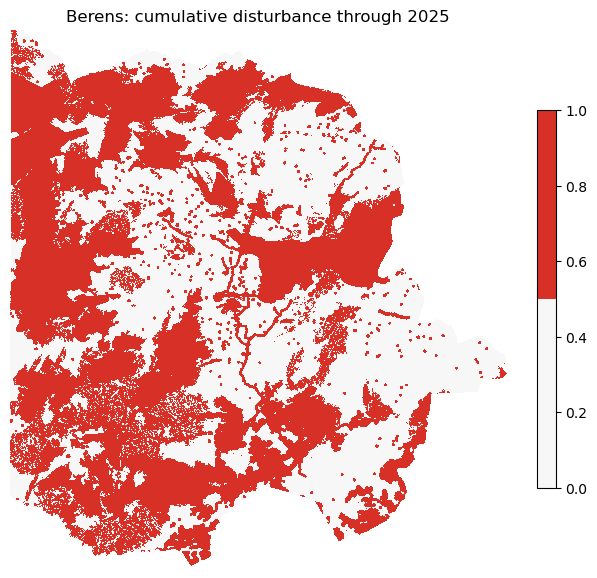

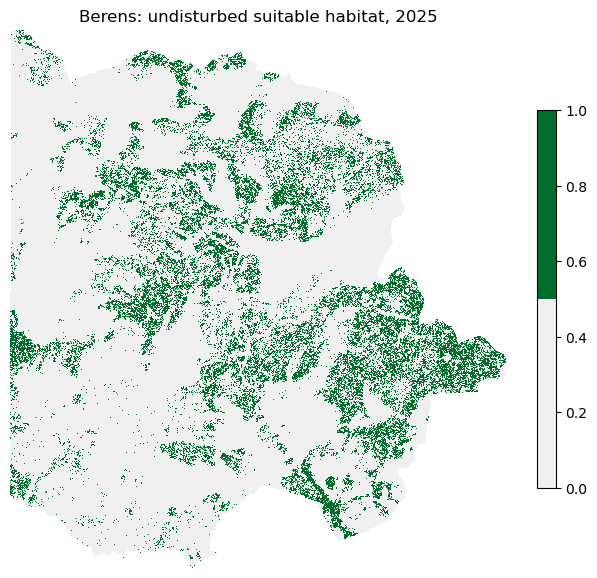

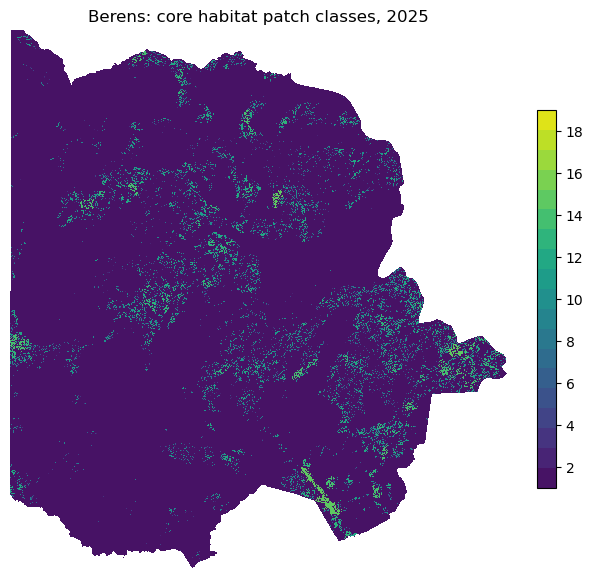

Building layers for Brightsand
  processing Brightsand, 2015


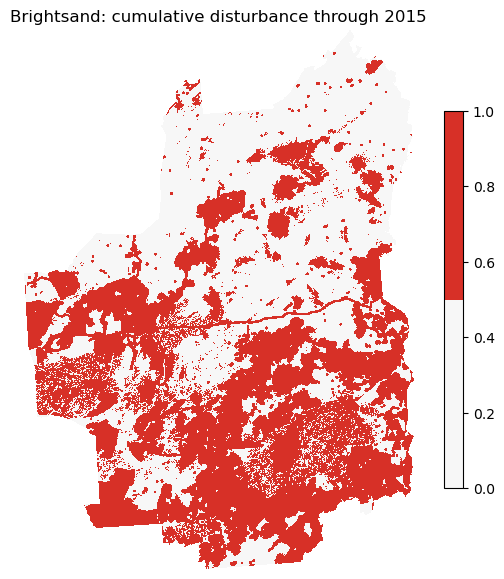

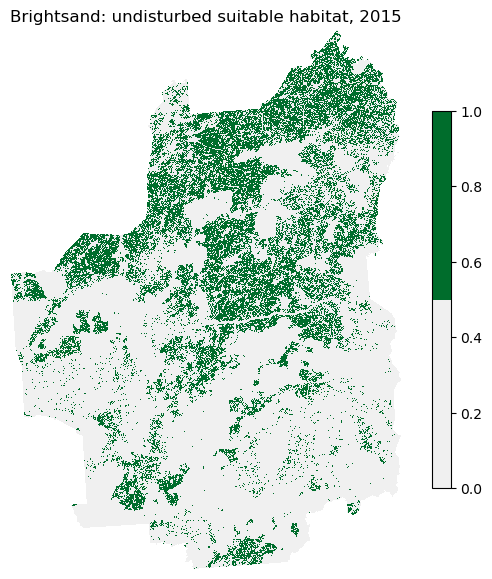

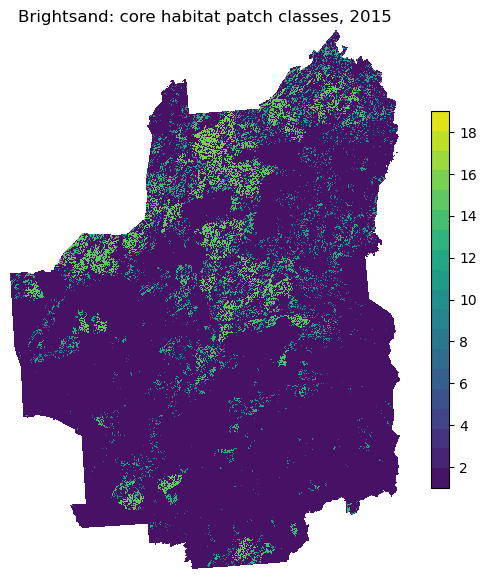

  processing Brightsand, 2016
  processing Brightsand, 2017
  processing Brightsand, 2018
  processing Brightsand, 2019
  processing Brightsand, 2020
  processing Brightsand, 2021
  processing Brightsand, 2022
  processing Brightsand, 2023
  processing Brightsand, 2024
  processing Brightsand, 2025


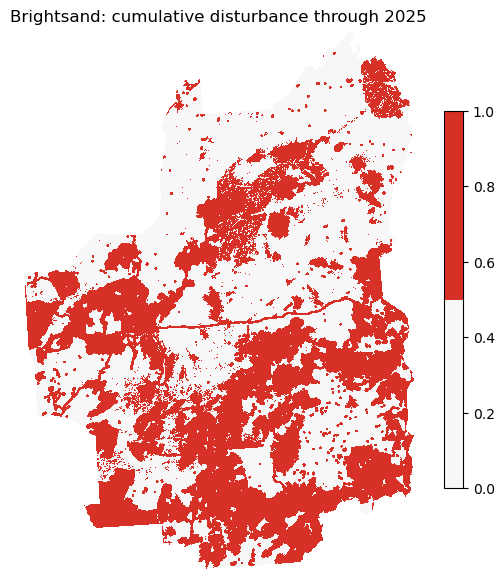

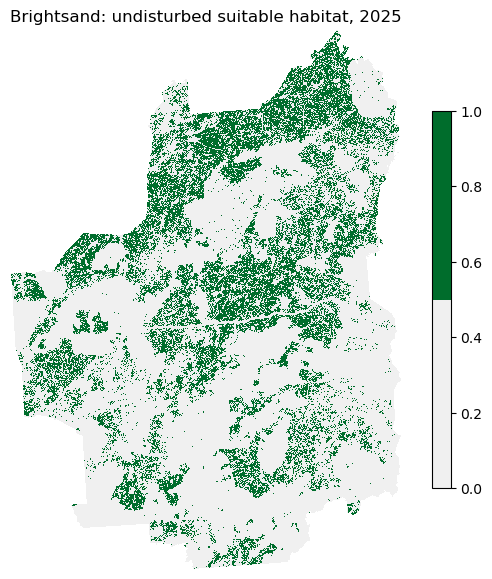

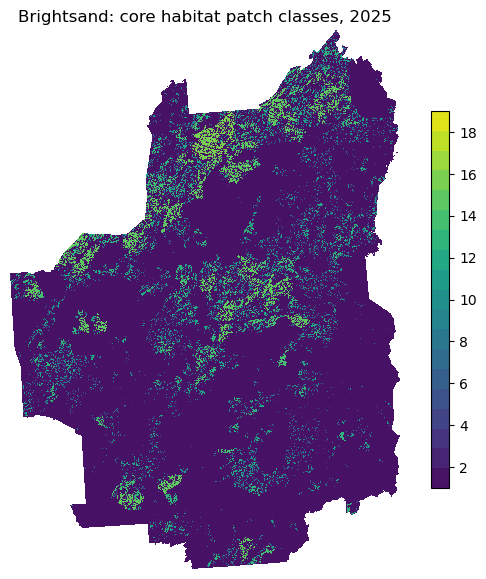

Building layers for Churchill
  processing Churchill, 2015


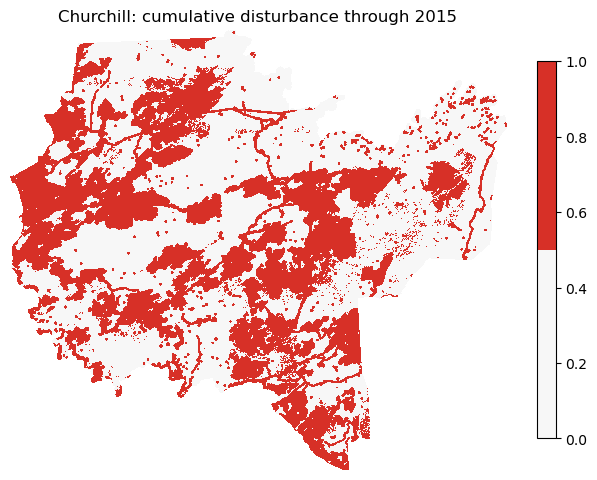

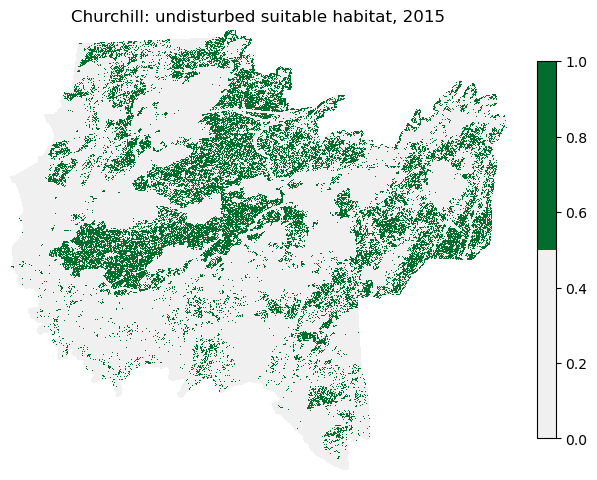

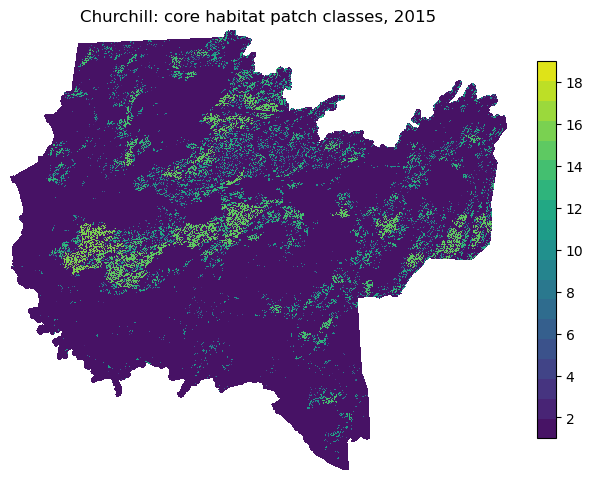

  processing Churchill, 2016
  processing Churchill, 2017
  processing Churchill, 2018
  processing Churchill, 2019
  processing Churchill, 2020
  processing Churchill, 2021
  processing Churchill, 2022
  processing Churchill, 2023
  processing Churchill, 2024
  processing Churchill, 2025


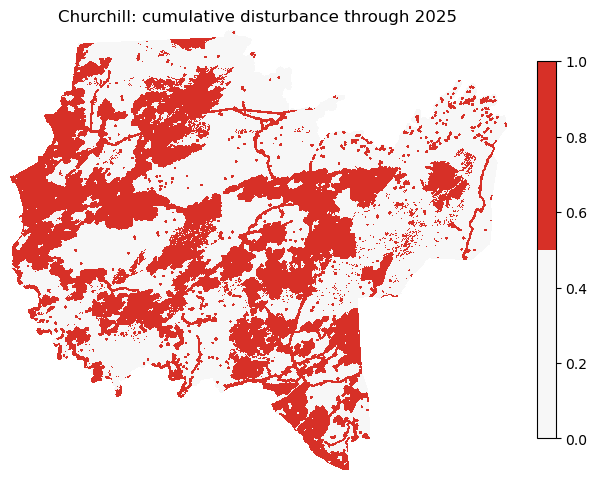

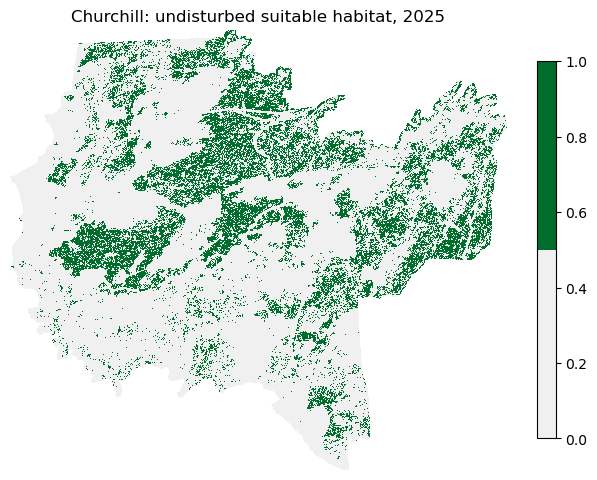

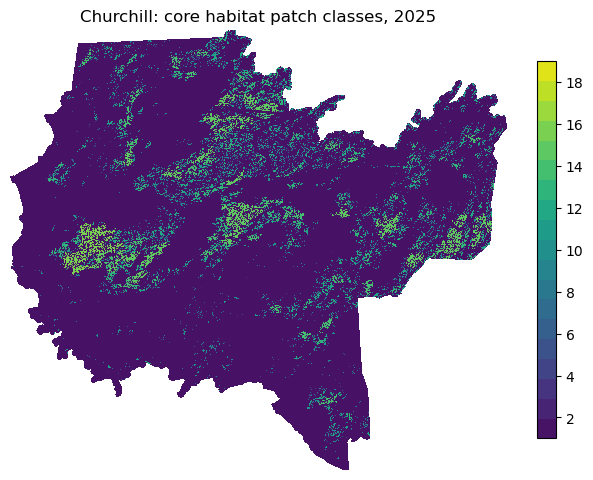

Building layers for Kesagami
  processing Kesagami, 2015


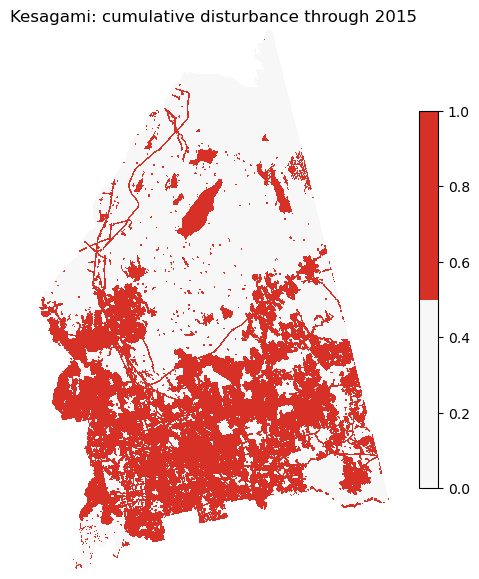

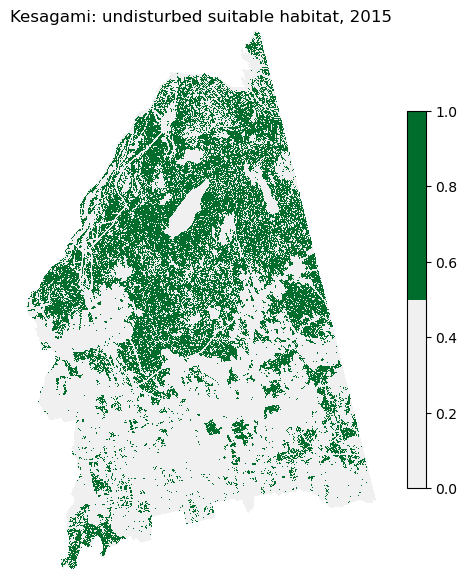

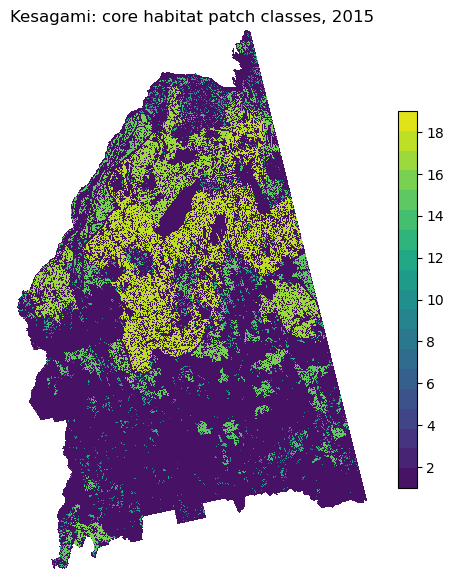

  processing Kesagami, 2016
  processing Kesagami, 2017
  processing Kesagami, 2018
  processing Kesagami, 2019
  processing Kesagami, 2020
  processing Kesagami, 2021
  processing Kesagami, 2022
  processing Kesagami, 2023
  processing Kesagami, 2024
  processing Kesagami, 2025


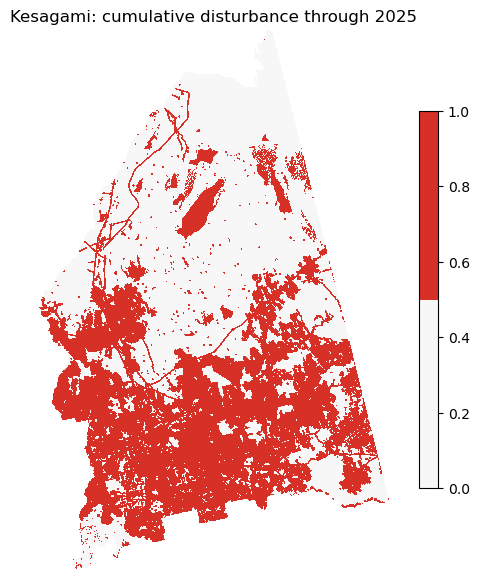

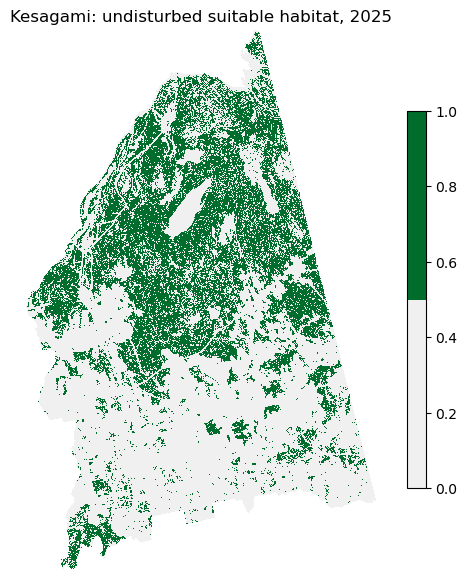

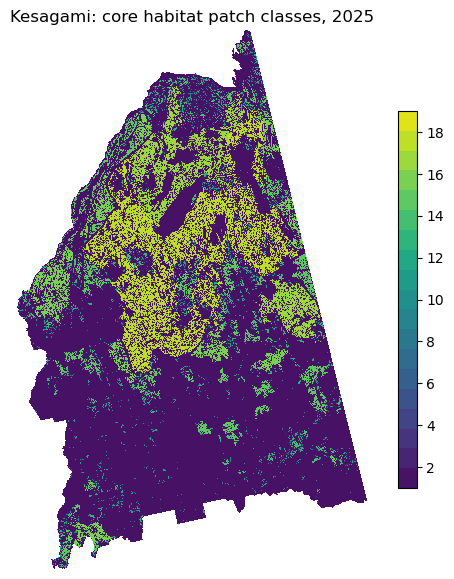

Building layers for Nipigon
  processing Nipigon, 2015


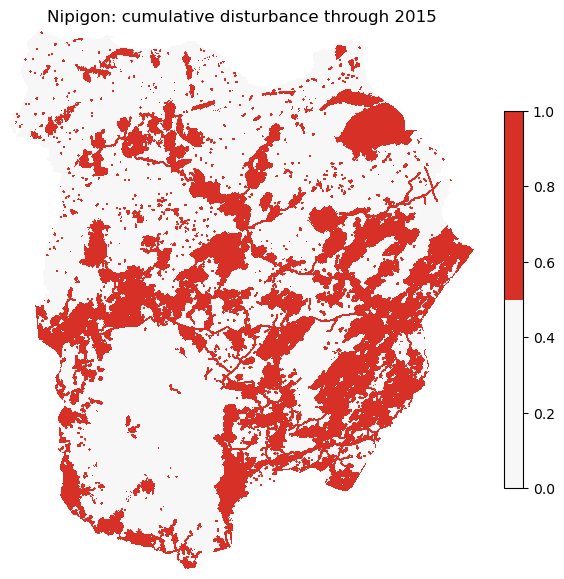

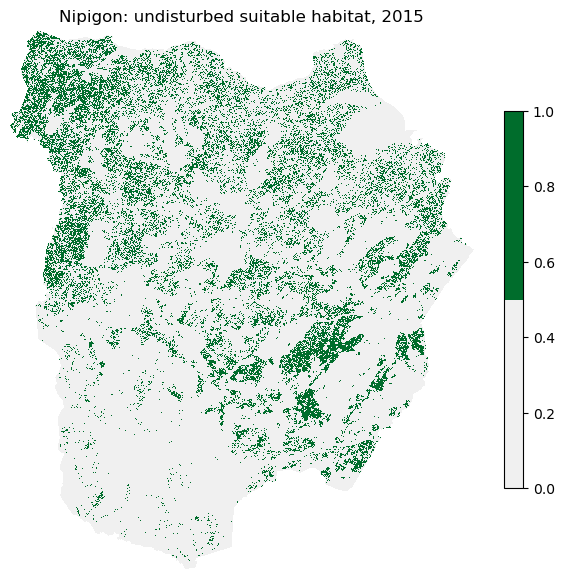

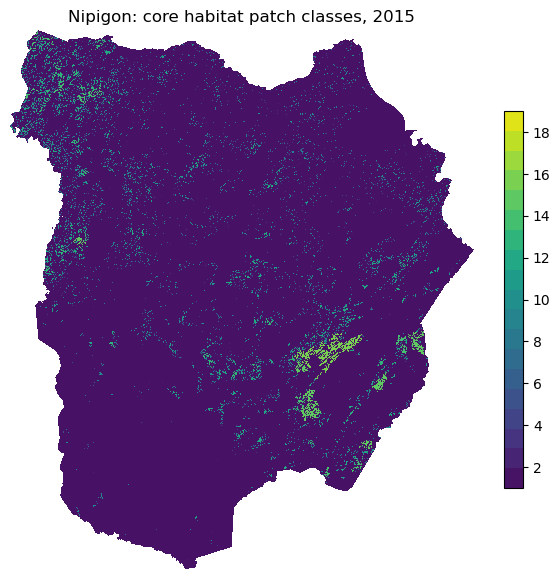

  processing Nipigon, 2016
  processing Nipigon, 2017
  processing Nipigon, 2018
  processing Nipigon, 2019
  processing Nipigon, 2020
  processing Nipigon, 2021
  processing Nipigon, 2022
  processing Nipigon, 2023
  processing Nipigon, 2024
  processing Nipigon, 2025


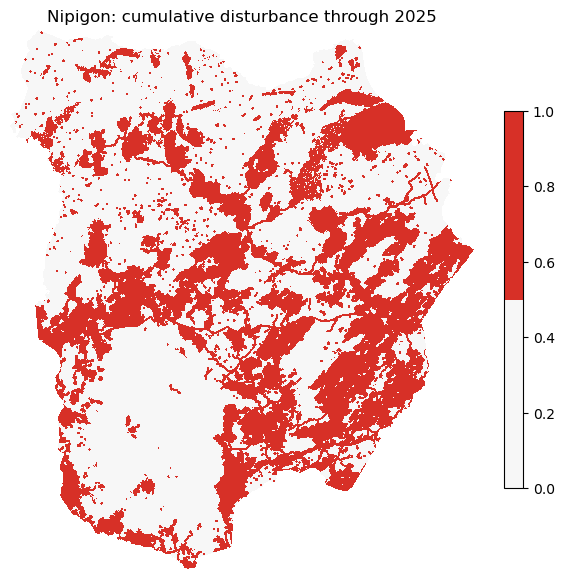

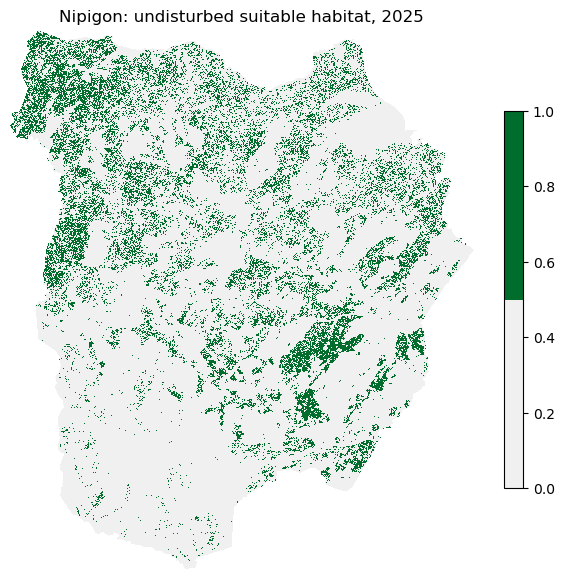

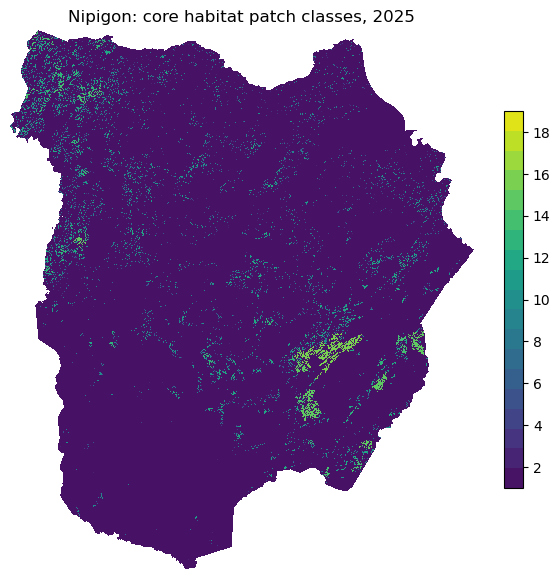

Building layers for Pagwachuan
  processing Pagwachuan, 2015


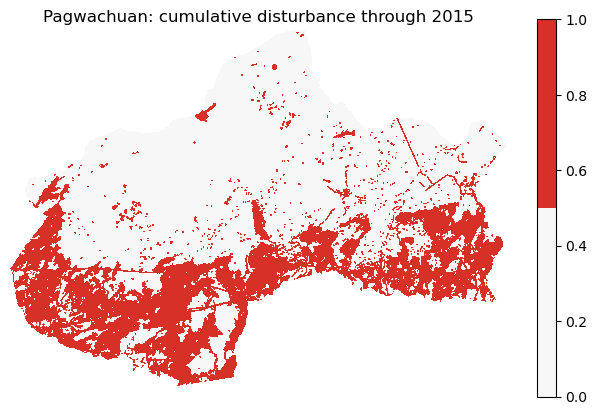

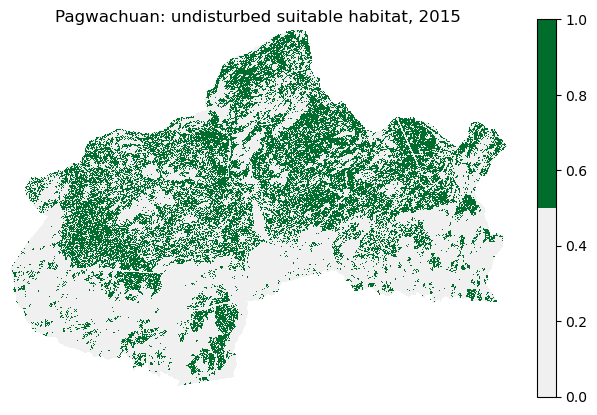

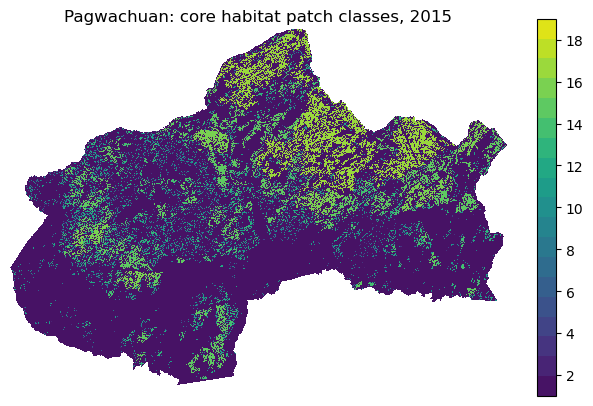

  processing Pagwachuan, 2016
  processing Pagwachuan, 2017
  processing Pagwachuan, 2018
  processing Pagwachuan, 2019
  processing Pagwachuan, 2020
  processing Pagwachuan, 2021
  processing Pagwachuan, 2022
  processing Pagwachuan, 2023
  processing Pagwachuan, 2024
  processing Pagwachuan, 2025


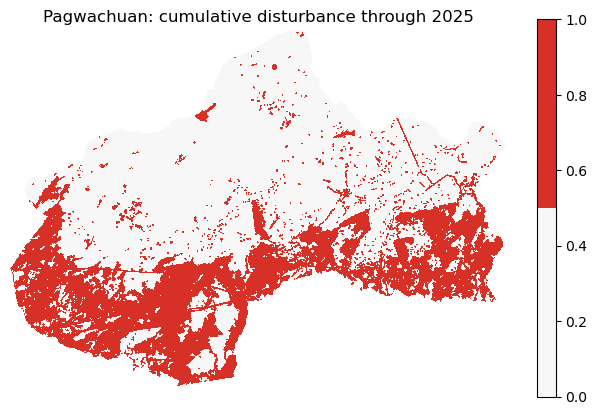

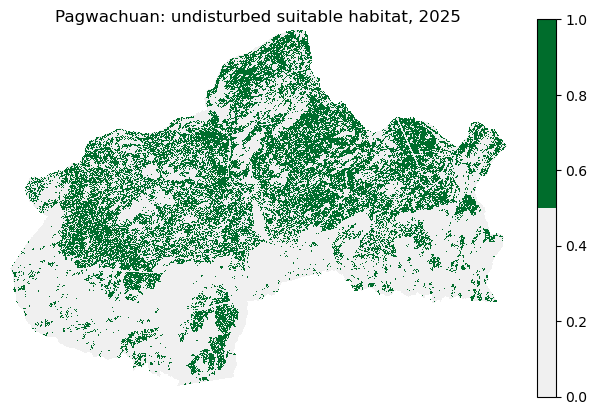

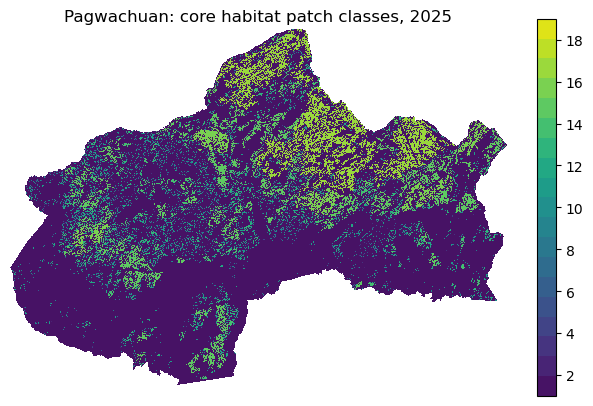

Building layers for Sydney
  processing Sydney, 2015


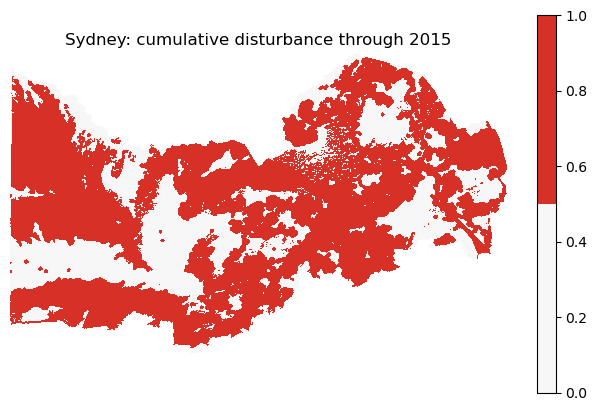

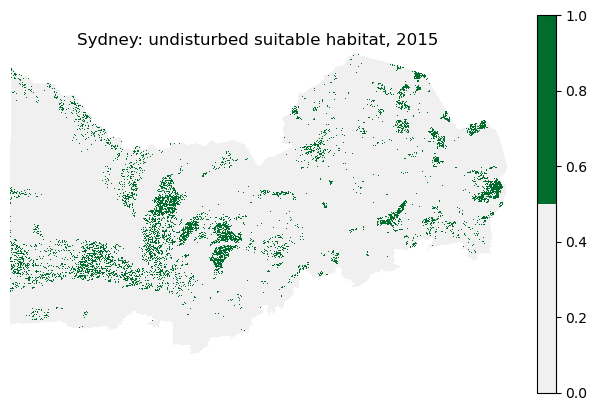

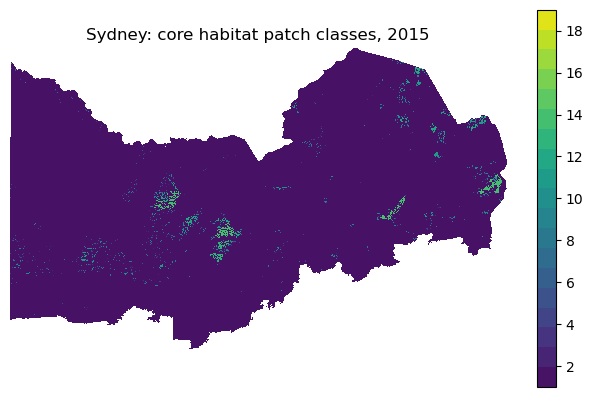

  processing Sydney, 2016
  processing Sydney, 2017
  processing Sydney, 2018
  processing Sydney, 2019
  processing Sydney, 2020
  processing Sydney, 2021
  processing Sydney, 2022
  processing Sydney, 2023
  processing Sydney, 2024
  processing Sydney, 2025


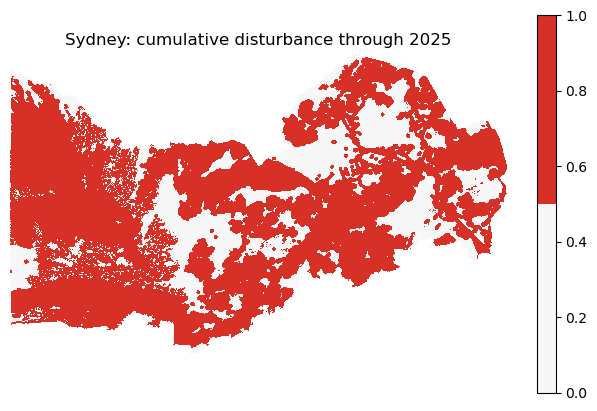

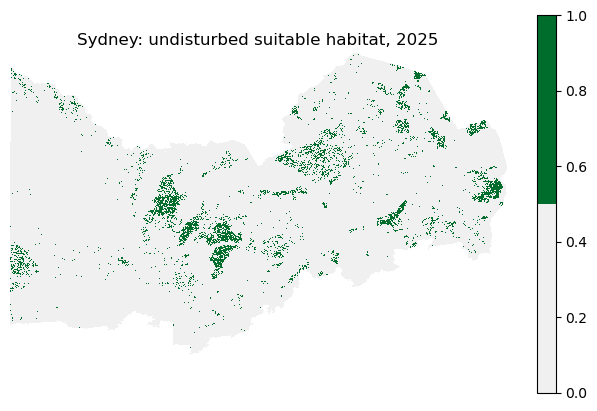

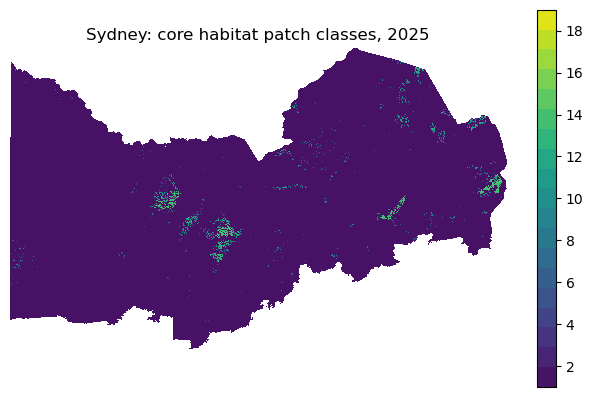


Harvest source contributions (1976 -> 2025):


,RANGE_NAME,range_ha,study_area_ha,ari_harvest_ha,national_harvest_ha,union_harvest_ha,added_by_national_ha,ari_footprint_pct,national_share_pct
0,Berens,2748714.5,1582194.1,57049.6,61743.2,73745.5,16943.3,44.3,23.0
1,Brightsand,2202667.7,1513391.0,278407.5,220229.1,317525.2,39349.2,36.2,12.4
2,Churchill,2110263.5,2010000.0,255248.2,225275.0,291146.8,35974.2,29.5,12.4
3,Kesagami,4729775.3,3360253.5,595655.2,404899.5,656061.5,63232.2,18.7,9.6
4,Nipigon,3826953.1,2897135.3,376774.9,285699.1,424086.4,48868.6,22.4,11.5
5,Pagwachuan,4484455.0,2150925.0,499526.8,396279.5,576486.8,78737.3,15.8,13.7
6,Sydney,741816.5,571530.2,86107.2,67655.2,99172.7,13082.9,49.3,13.2


,RANGE_NAME,YEAR,range_area_ha,potential_habitat_ha,harvest_buffered_ha,fire_ha,eccc_ha,disturbed_area_ha,undisturbed_habitat_ha,core_habitat_ha,core_patch_count,study_area_ha,potential_habitat_study_ha,disturbed_area_study_ha,undisturbed_habitat_study_ha,core_habitat_study_ha,disturbance_percent,risk_class,disturbance_percent_study,risk_class_study
0,Berens,2015,2748714.5,767673.7,257444.2,268239.7,1122526.3,1284097.6,551053.9,208569.2,59905,1582194.1,494685.4,634918.8,377089.6,149331.3,46.7,High,40.1,Moderate
11,Brightsand,2015,2202667.7,913811.0,707042.9,288787.9,767925.0,1063064.9,575044.0,279617.6,43769,1513391.0,558981.8,923683.4,264458.4,129004.0,48.3,High,61.0,High
22,Churchill,2015,2110263.5,738957.9,647363.5,116071.6,750376.4,878949.6,519175.5,256014.1,38858,2010000.0,706970.2,863997.0,491981.6,242868.7,41.7,Moderate,43.0,Moderate
33,Kesagami,2015,4729775.3,2727673.1,1479167.6,80618.2,1931491.3,2042177.1,1786173.1,1239887.4,44768,3360253.5,1861578.2,1897714.1,987499.4,691635.7,43.2,Moderate,56.5,High
44,Nipigon,2015,3826953.1,979510.0,1018011.5,154765.8,1213131.4,1381539.6,678583.2,217524.2,88291,2897135.3,827327.6,1280510.1,543231.4,174166.3,36.1,Moderate,44.2,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32,Churchill,2025,2110263.5,738957.9,732711.1,123387.3,750376.4,919409.3,494711.2,241336.5,37796,2010000.0,706970.2,904282.5,467579.2,228214.4,43.6,Moderate,45.0,Moderate
43,Kesagami,2025,4729775.3,2727673.1,1609670.2,143202.4,1931491.3,2139452.2,1714672.0,1189538.9,42808,3360253.5,1861578.2,1967129.8,940182.5,660848.2,45.2,High,58.5,High
54,Nipigon,2025,3826953.1,979510.0,1109544.8,221401.6,1213131.4,1476035.8,643205.8,207062.3,83355,2897135.3,827327.6,1355507.0,516252.8,166321.4,38.6,Moderate,46.8,High
65,Pagwachuan,2025,4484455.0,2115511.5,1359135.6,21847.0,1312181.6,1549217.5,1637443.5,962012.6,85383,2150925.0,839303.5,1411356.0,424127.5,225505.4,34.5,Low,65.6,High


In [7]:
def process_range_year(name, L, year, show):
    key = safe_name(name)
    potential, profile, valid, study = L['potential'], L['profile'], L['valid'], L['study']

    harvest = (L['harvest_year'] >= HARVEST_START) & (L['harvest_year'] <= year)
    harvest_buffered = buffer_metres(harvest)
    # Natural disturbance recovers after FIRE_WINDOW_YEARS; anthropogenic does not.
    natural_start = year - FIRE_WINDOW_YEARS if FIRE_WINDOW_YEARS else FIRE_START
    fire = (L['fire_year'] >= natural_start) & (L['fire_year'] <= year)
    other = (L['other_year'] >= natural_start) & (L['other_year'] <= year)

    disturbance = (harvest_buffered | fire | other | L['eccc']) & valid
    undisturbed = (potential == 1) & ~disturbance & valid
    core_classes, patch_count, core = core_size_classes(undisturbed, valid)

    dist_out = np.where(valid, disturbance.astype('uint8'), NODATA).astype('uint8')
    und_out = np.where(valid, undisturbed.astype('uint8'), NODATA).astype('uint8')
    dist_tif = OUT / '02_disturbance' / ('%s_total_disturbance_%d.tif' % (key, year))
    und_tif = OUT / '03_undisturbed_habitat' / ('%s_undisturbed_habitat_%d.tif' % (key, year))
    core_tif = OUT / '05_mspa' / ('%s_core_patch_size_class_%d.tif' % (key, year))
    write_raster(dist_tif, dist_out, profile)
    write_raster(und_tif, und_out, profile)
    write_raster(core_tif, core_classes, profile)

    plot_mask(dist_tif, '%s: cumulative disturbance through %d' % (name, year),
              OUT / 'figures' / ('%s_02_disturbance_%d.png' % (key, year)),
              ListedColormap(['#f7f7f7', '#d73027']), show=show)
    plot_mask(und_tif, '%s: undisturbed suitable habitat, %d' % (name, year),
              OUT / 'figures' / ('%s_03_undisturbed_habitat_%d.png' % (key, year)),
              ListedColormap(['#f0f0f0', '#006d2c']), show=show)
    plot_mask(core_tif, '%s: core habitat patch classes, %d' % (name, year),
              OUT / 'figures' / ('%s_05_core_habitat_%d.png' % (key, year)),
              ListedColormap(plt.cm.viridis(np.linspace(0.05, 0.95, 19))), vmin=1, vmax=19, show=show)

    # Two sets of statistics: over the whole provincial range, and over the paper's
    # analysis boundary (range within the Area of Undertaking).
    return {'RANGE_NAME': name, 'YEAR': year,
            'range_area_ha': valid.sum() * PIXEL_HA,
            'potential_habitat_ha': ((potential == 1) & valid).sum() * PIXEL_HA,
            'harvest_buffered_ha': (harvest_buffered & valid).sum() * PIXEL_HA,
            'fire_ha': (fire & valid).sum() * PIXEL_HA,
            'eccc_ha': (L['eccc'] & valid).sum() * PIXEL_HA,
            'disturbed_area_ha': disturbance.sum() * PIXEL_HA,
            'undisturbed_habitat_ha': undisturbed.sum() * PIXEL_HA,
            'core_habitat_ha': core.sum() * PIXEL_HA,
            'core_patch_count': patch_count,
            'study_area_ha': study.sum() * PIXEL_HA,
            'potential_habitat_study_ha': ((potential == 1) & study).sum() * PIXEL_HA,
            'disturbed_area_study_ha': (disturbance & study).sum() * PIXEL_HA,
            'undisturbed_habitat_study_ha': (undisturbed & study).sum() * PIXEL_HA,
            'core_habitat_study_ha': (core & study).sum() * PIXEL_HA}

results, contributions = [], []
for _, row in ranges.iterrows():
    print('Building layers for %s' % row.RANGE_NAME, flush=True)
    layers, contribution = build_range_layers(row)
    contributions.append(contribution)
    for year in TARGET_YEARS:
        print('  processing %s, %d' % (row.RANGE_NAME, year), flush=True)
        results.append(process_range_year(row.RANGE_NAME, layers, year,
                                          show=year in (TARGET_YEARS[0], TARGET_YEARS[-1])))
    del layers

contributions = pd.DataFrame(contributions)
contributions['national_share_pct'] = 100 * contributions.added_by_national_ha / contributions.union_harvest_ha
contributions.to_csv(OUT / '04_statistics' / 'harvest_source_contributions.csv', index=False)
print()
print('Harvest source contributions (%d -> %d):' % (HARVEST_START, TARGET_YEARS[-1]))
display(contributions.round(1))

RISK_BINS = [-np.inf, 10, 35, 45, 75, np.inf]
RISK_LABELS = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']

annual_stats = pd.DataFrame(results)
annual_stats['disturbance_percent'] = 100 * annual_stats.disturbed_area_ha / annual_stats.range_area_ha
annual_stats['risk_class'] = pd.cut(annual_stats.disturbance_percent, bins=RISK_BINS, labels=RISK_LABELS)
annual_stats['disturbance_percent_study'] = (100 * annual_stats.disturbed_area_study_ha
                                             / annual_stats.study_area_ha)
annual_stats['risk_class_study'] = pd.cut(annual_stats.disturbance_percent_study,
                                          bins=RISK_BINS, labels=RISK_LABELS)
annual_stats.to_csv(OUT / '04_statistics' / 'annual_caribou_habitat_statistics_2015_2025.csv', index=False)
display(annual_stats.sort_values(['YEAR', 'RANGE_NAME']).round(1))

## 8. Figure 6-style annual overview maps

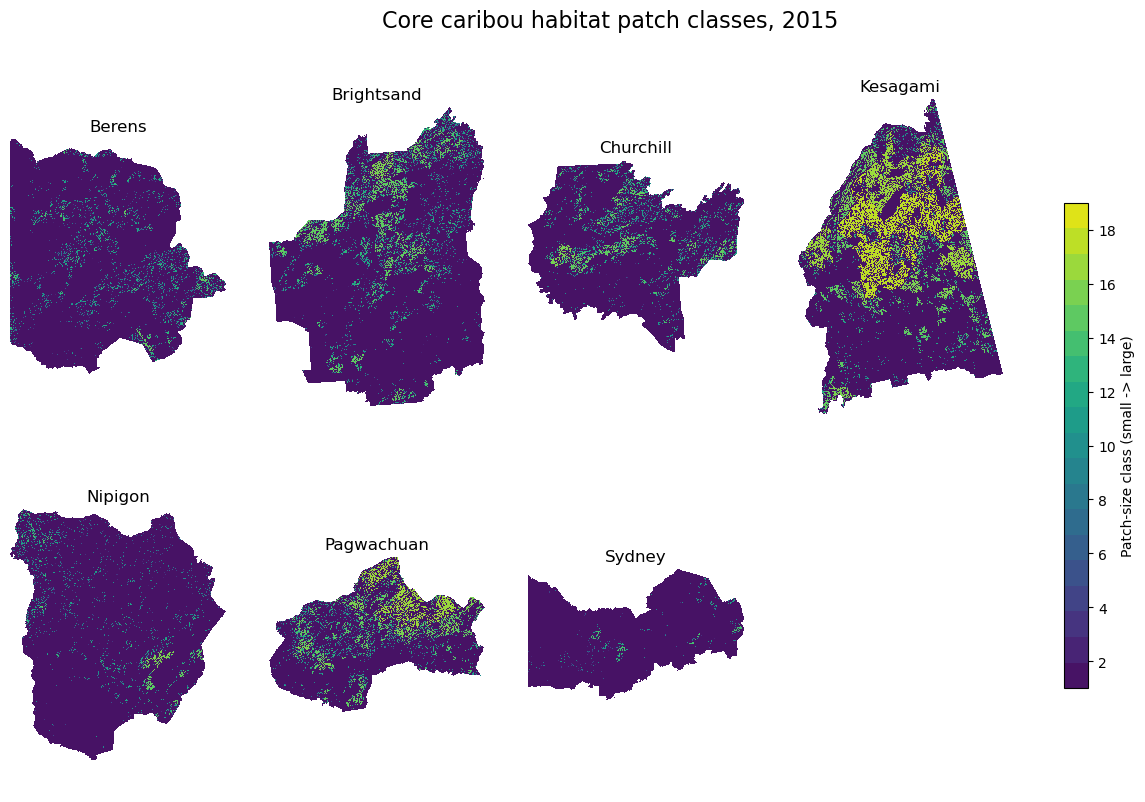

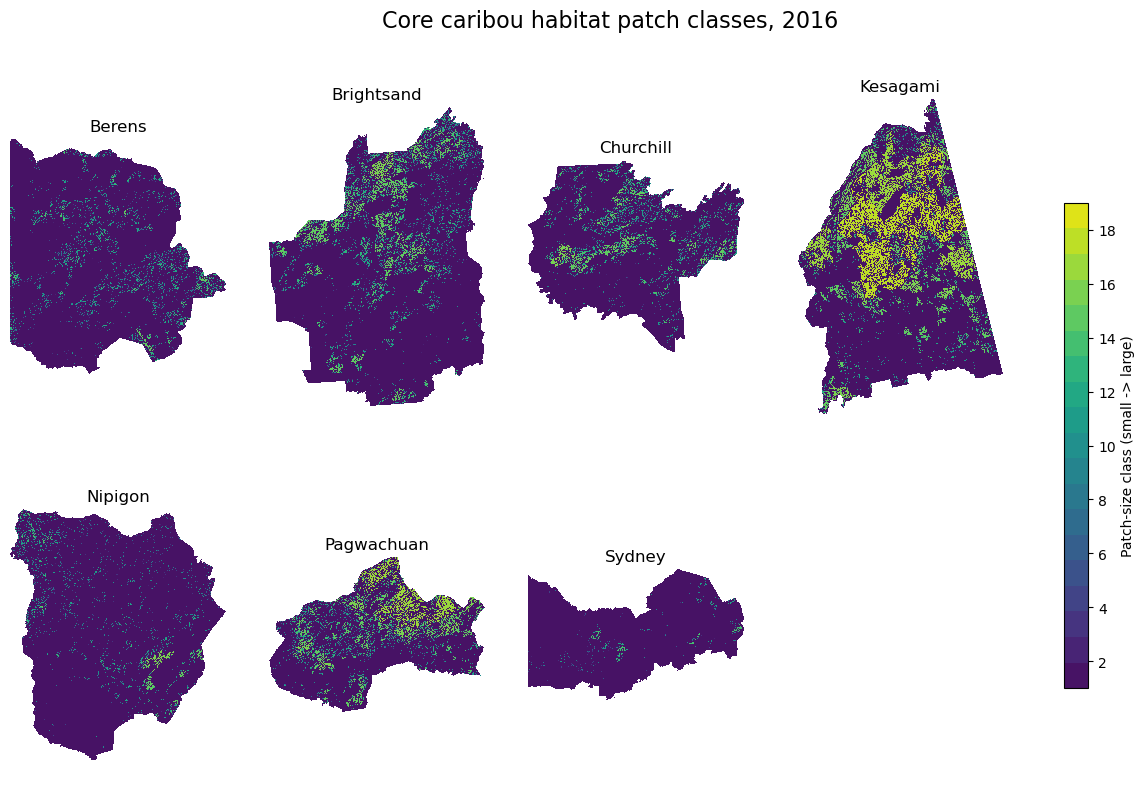

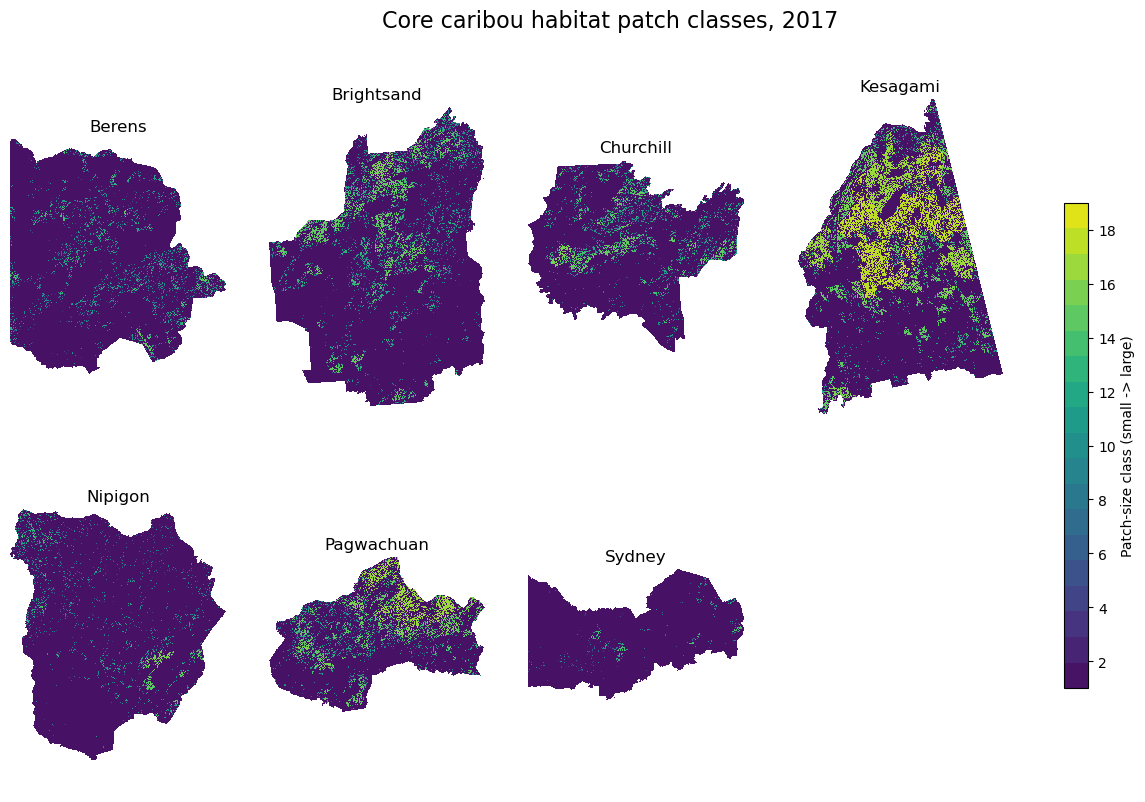

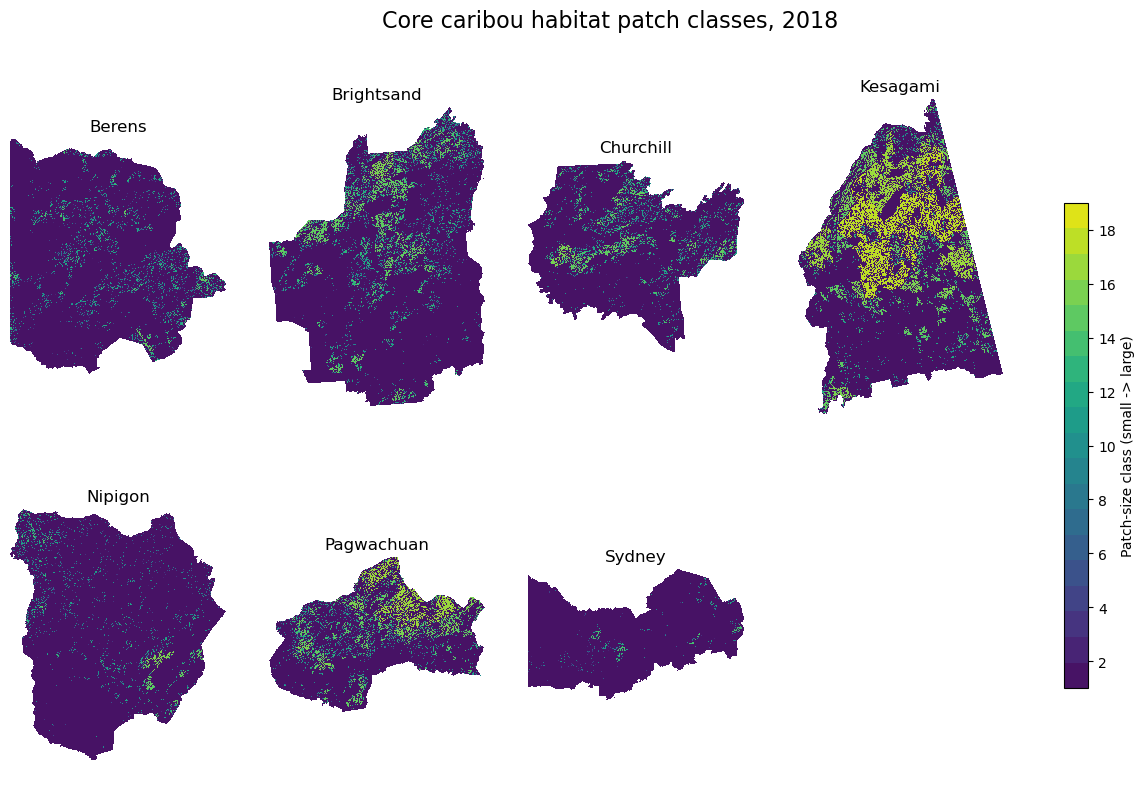

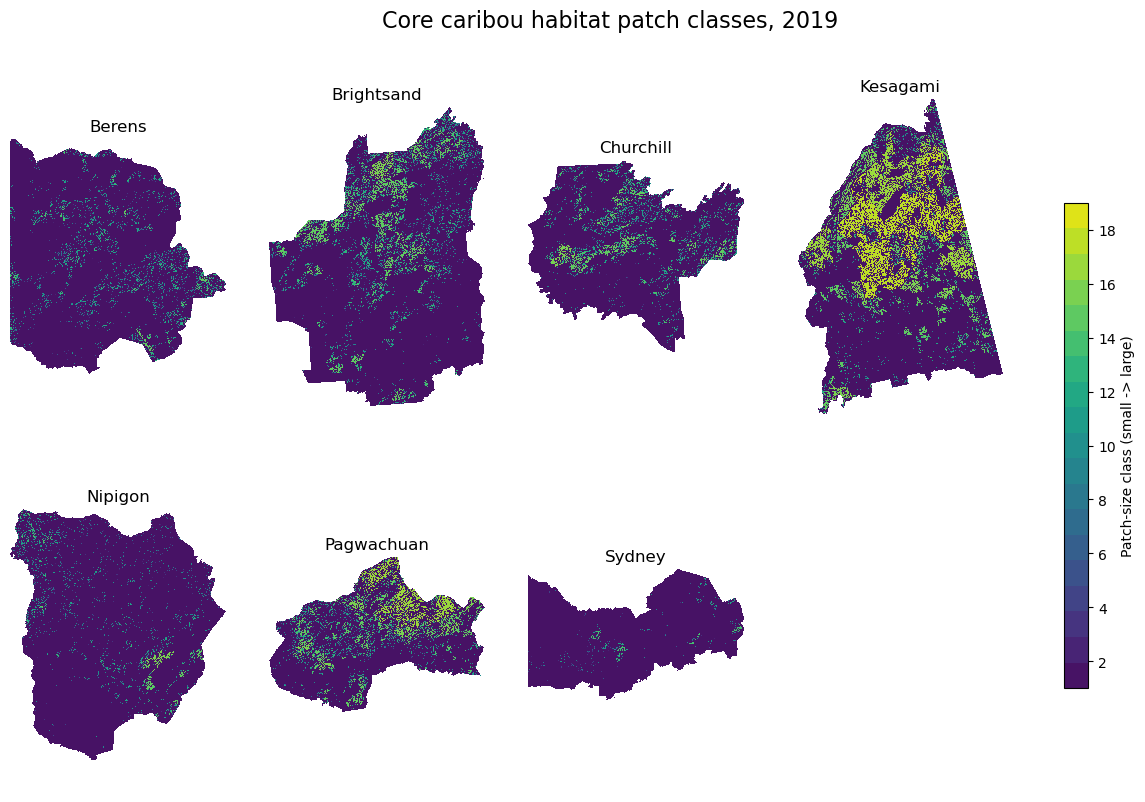

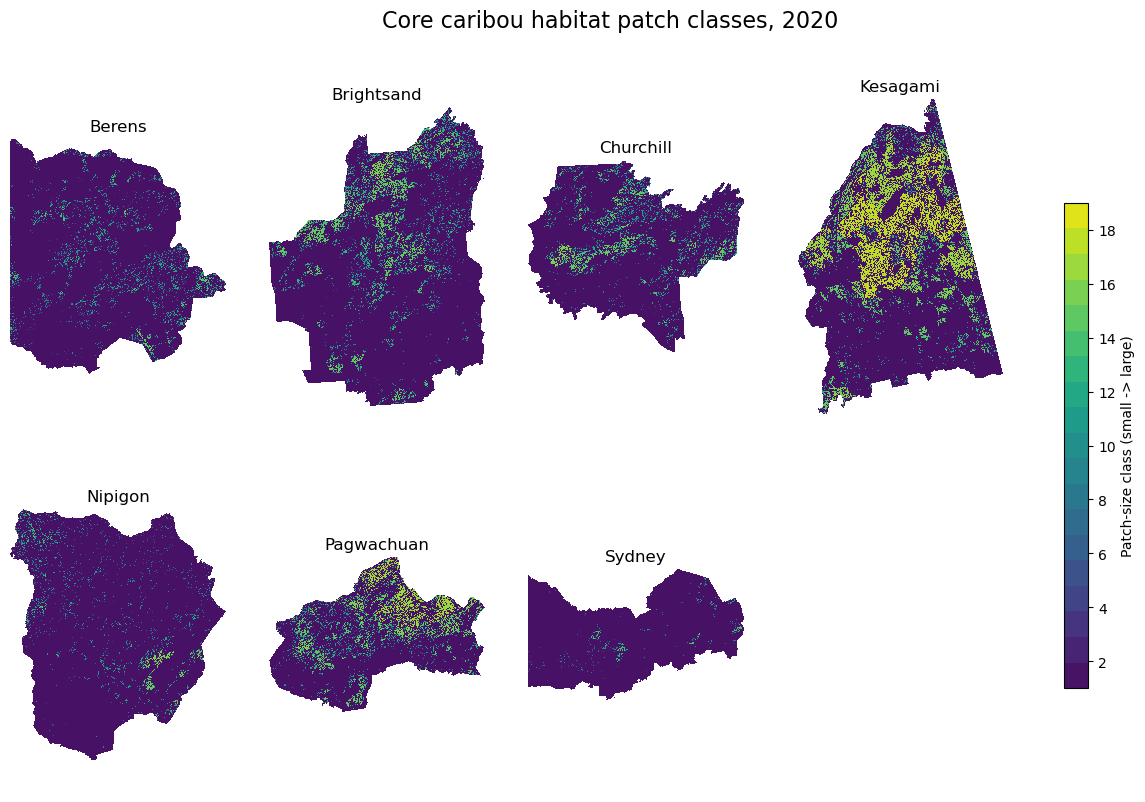

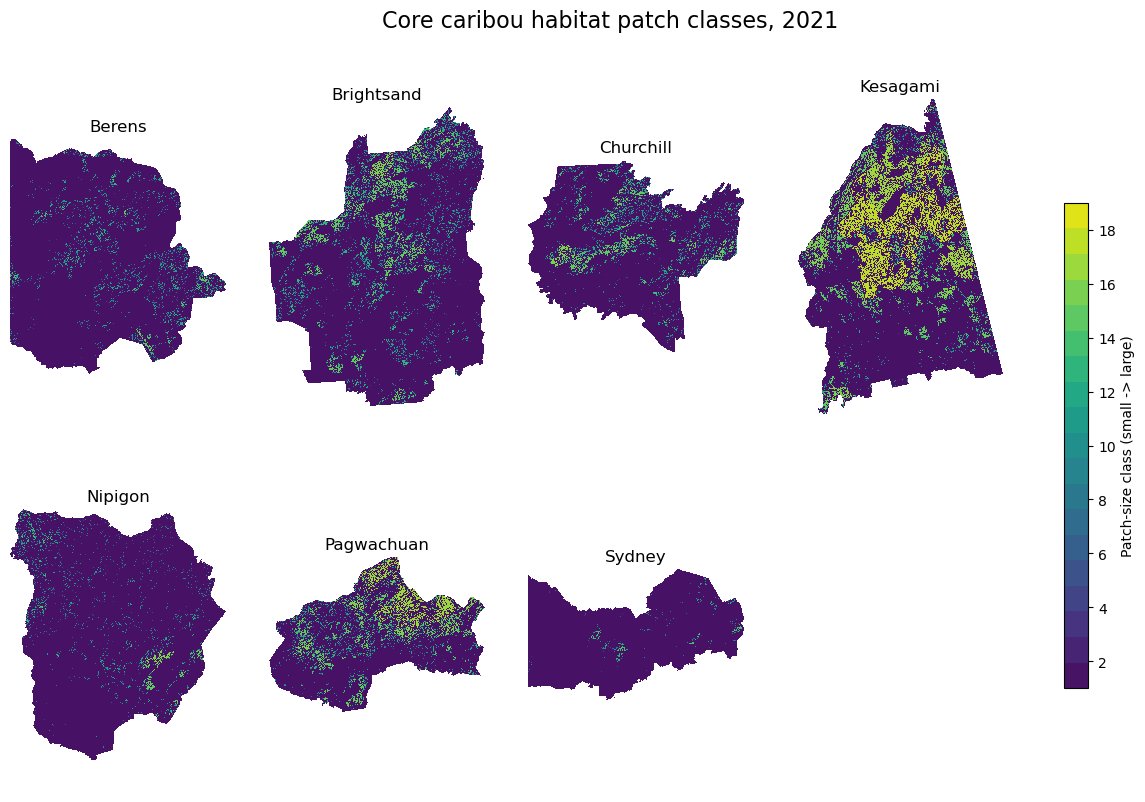

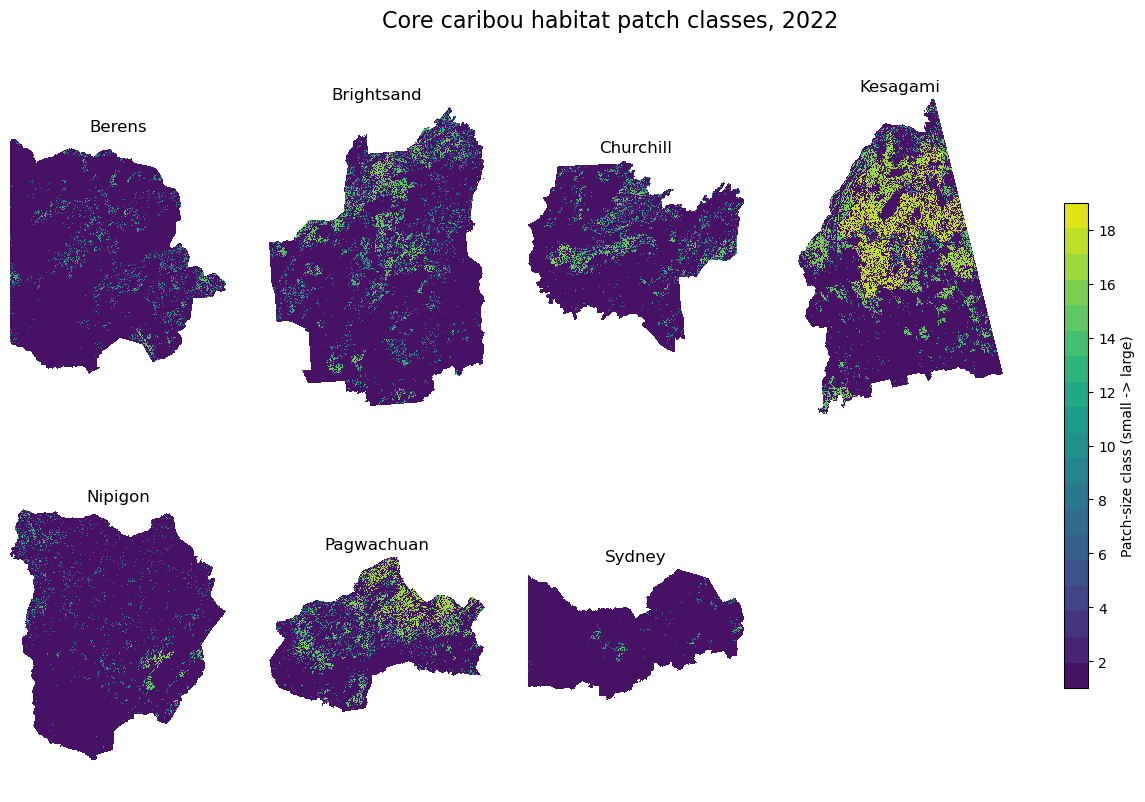

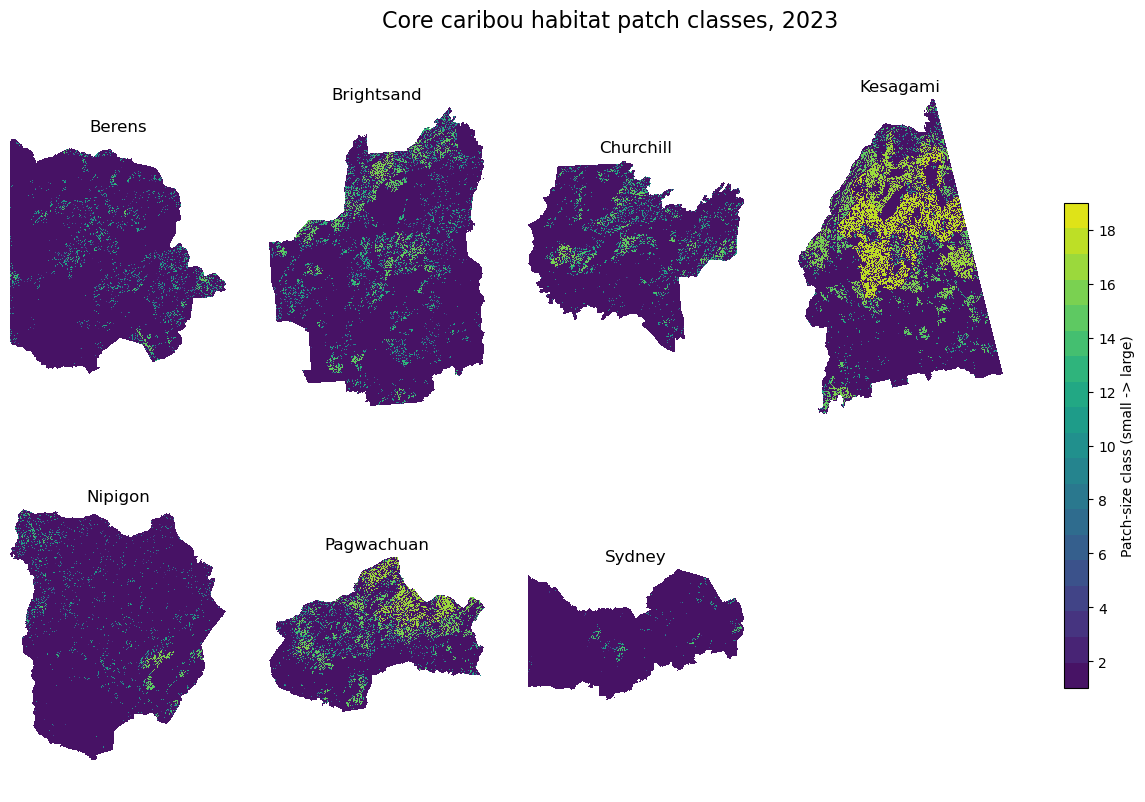

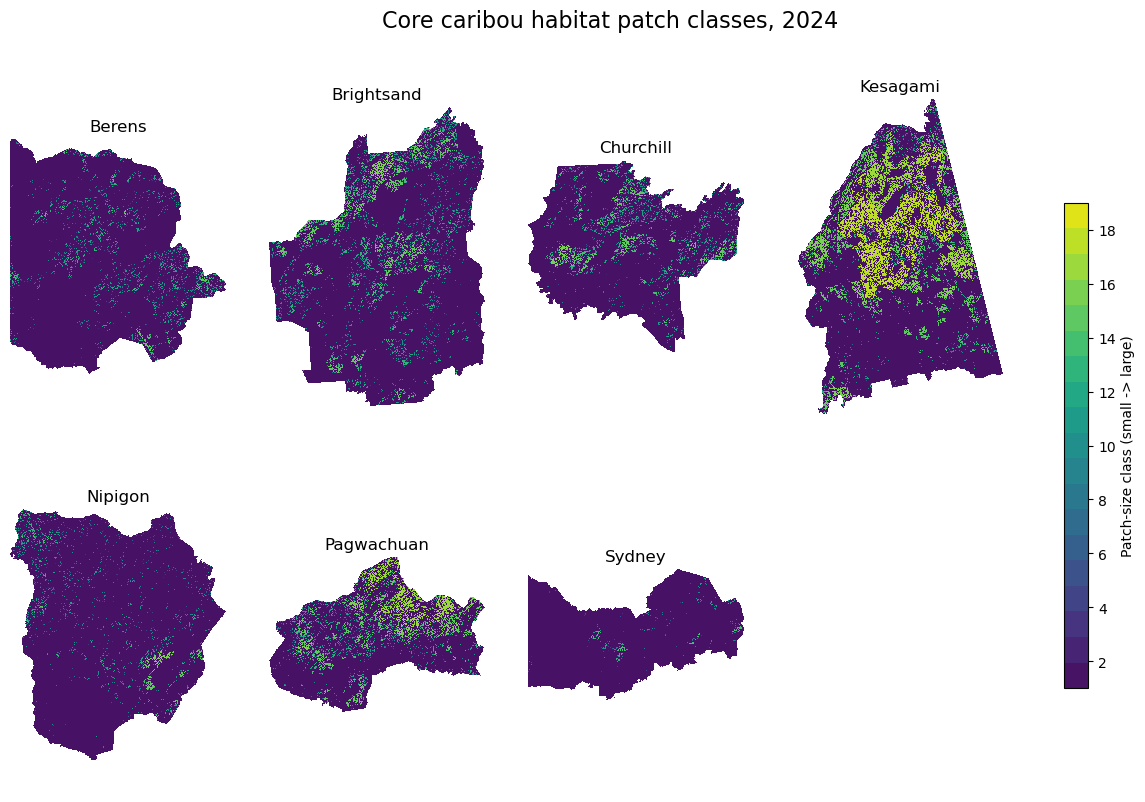

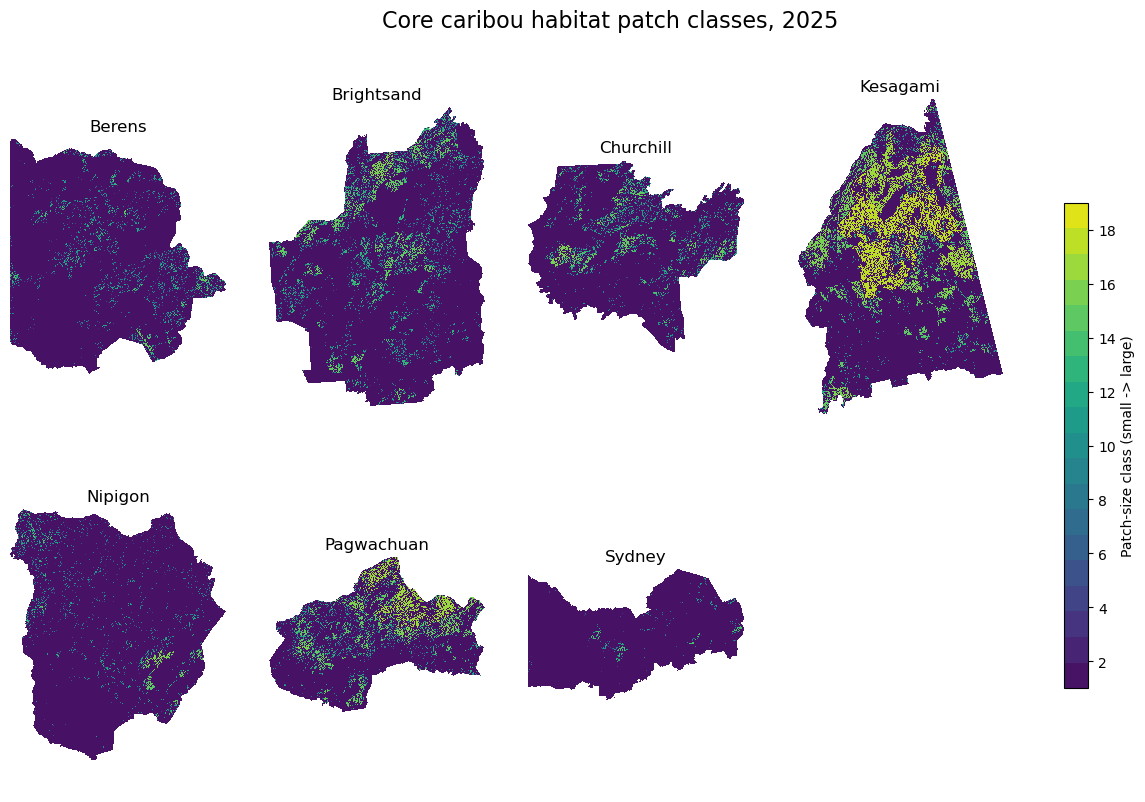

In [8]:
patch_cmap = ListedColormap(plt.cm.viridis(np.linspace(0.05, 0.95, 19)))
for year in TARGET_YEARS:
    fig, axes = plt.subplots(2, 4, figsize=(16, 9))
    axes = axes.ravel()
    image = None
    for ax, name in zip(axes, PAPER_RANGES):
        tif = OUT / '05_mspa' / ('%s_core_patch_size_class_%d.tif' % (safe_name(name), year))
        with rasterio.open(tif) as ds:
            image = ax.imshow(ds.read(1, masked=True), cmap=patch_cmap, vmin=1, vmax=19,
                              interpolation='nearest')
        ax.set_title(name)
        ax.set_axis_off()
    axes[-1].set_axis_off()
    fig.suptitle('Core caribou habitat patch classes, %d' % year, fontsize=16)
    fig.colorbar(image, ax=axes.tolist(), shrink=0.7, label='Patch-size class (small -> large)')
    fig.savefig(OUT / 'figures' / ('figure6_style_core_habitat_%d.png' % year), dpi=200, bbox_inches='tight')
    plt.show()

## 9. Trends, QA and comparison with the paper

The final table compares this run against Mackey et al. Table 4. The paper's habitat column is a
differently-defined quantity (it sums to 11.77 M ha across 21 ranges, while the paper's MSPA core
total is 6.10 M ha), so treat the habitat comparison as indicative and the disturbance percentage as
the like-for-like test.

QA passed: core <= undisturbed <= potential, and disturbance <= range area.

Disturbance % by year, full provincial range:


YEAR,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
RANGE_NAME,,,,,,,,,,,
Berens,46.7,46.6,45.9,45.8,46.0,46.1,53.0,53.2,53.3,53.0,52.7
Brightsand,48.3,48.2,47.7,47.8,47.8,47.9,42.9,43.2,46.3,46.2,46.2
Churchill,41.7,41.7,41.6,41.7,41.8,41.7,42.1,42.5,43.6,43.6,43.6
Kesagami,43.2,43.2,43.2,43.2,43.3,43.3,44.3,44.3,45.1,45.2,45.2
Nipigon,36.1,36.1,36.2,36.2,36.3,36.4,36.6,36.9,38.6,38.6,38.6
Pagwachuan,32.9,33.0,33.1,33.2,33.2,33.6,34.1,34.3,34.5,34.5,34.5
Sydney,67.6,67.7,67.6,67.7,67.8,67.8,72.8,72.9,73.1,72.8,72.8


Disturbance % by year, paper analysis boundary (range within AoU):


YEAR,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
RANGE_NAME,,,,,,,,,,,
Berens,40.1,40.2,38.9,38.8,39.0,39.1,44.4,44.6,44.7,44.5,44.5
Brightsand,61.0,60.9,60.5,60.6,60.6,60.8,53.5,53.9,54.5,54.5,54.4
Churchill,43.0,43.0,42.9,43.0,43.1,43.1,43.4,43.9,45.0,45.0,45.0
Kesagami,56.5,56.5,56.5,56.5,56.5,56.7,58.0,58.0,58.5,58.5,58.5
Nipigon,44.2,44.2,44.3,44.3,44.4,44.5,44.8,45.2,46.8,46.8,46.8
Pagwachuan,63.2,63.3,63.4,63.4,63.5,64.1,64.8,65.2,65.6,65.6,65.6
Sydney,66.5,66.5,66.5,66.5,66.6,66.7,70.1,70.3,70.6,70.1,70.1


Core habitat (ha) by year:


YEAR,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
RANGE_NAME,,,,,,,,,,,
Berens,208569.0,208809.0,210957.0,211010.0,210381.0,209792.0,178555.0,177077.0,176404.0,176753.0,176999.0
Brightsand,279618.0,279816.0,283408.0,283298.0,283258.0,282533.0,302380.0,300019.0,270130.0,270130.0,270238.0
Churchill,256014.0,255762.0,256662.0,256198.0,255698.0,256148.0,254173.0,251886.0,241489.0,241337.0,241337.0
Kesagami,1239887.0,1239582.0,1238659.0,1237656.0,1237526.0,1235188.0,1219746.0,1219378.0,1194583.0,1189539.0,1189539.0
Nipigon,217524.0,217430.0,217290.0,217220.0,217124.0,216547.0,215424.0,213712.0,207060.0,207060.0,207062.0
Pagwachuan,980926.0,980172.0,979158.0,977797.0,977337.0,973809.0,967342.0,965087.0,962052.0,962013.0,962013.0
Sydney,15195.0,15149.0,15327.0,15322.0,15278.0,15261.0,13083.0,12970.0,12816.0,13037.0,13038.0


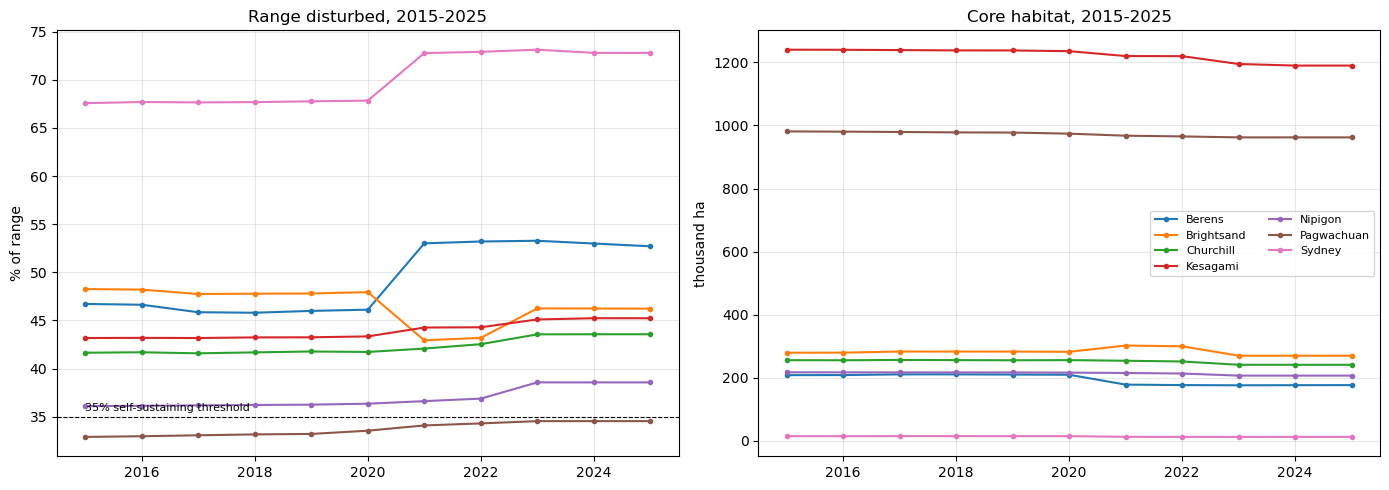


2020 vs Mackey et al. Table 4:


,RANGE_NAME,range_area_ha,study_area_ha,disturbance_percent,disturbance_percent_study,risk_class,risk_class_study,core_habitat_ha,core_habitat_study_ha,paper_range_ha,paper_habitat_ha,paper_pct_disturbed,area_ratio,gap_full,gap_study
0,Berens,2748714.48,1582194.06,46.12,39.13,High,Moderate,209792.25,150340.05,1612106,369895,46.4,0.98,-0.28,-7.27
1,Brightsand,2202667.74,1513390.95,47.94,60.80,High,High,282533.13,130697.55,1525297,241067,65.6,0.99,-17.66,-4.80
2,Churchill,2110263.48,2009999.97,41.73,43.06,Moderate,Moderate,256147.92,243024.84,2035815,427948,49.0,0.99,-7.27,-5.94
3,Kesagami,4729775.31,3360253.50,43.35,56.66,Moderate,High,1235187.81,687605.76,3373204,1042716,53.5,1.00,-10.15,3.16
4,Nipigon,3826953.09,2897135.28,36.36,44.50,Moderate,Moderate,216546.75,173317.23,2928933,243926,74.4,0.99,-38.04,-29.90
5,Pagwachuan,4484455.02,2150925.03,33.55,64.10,Low,High,973808.91,234658.71,2165773,408060,67.8,0.99,-34.25,-3.70
6,Sydney,741816.54,571530.15,67.83,66.71,High,High,15260.58,12541.41,578902,69528,50.0,0.99,17.83,16.71


mean absolute error in %% disturbed:
   full provincial range : 17.9 points
   paper analysis boundary (range within AoU): 10.2 points
risk class matches (paper has all seven at High):
   full range : 3/7
   study area : 4/7


In [9]:
qa = annual_stats
assert (qa.undisturbed_habitat_ha <= qa.potential_habitat_ha + 1e-6).all()
assert (qa.core_habitat_ha <= qa.undisturbed_habitat_ha + 1e-6).all()
assert (qa.disturbed_area_ha <= qa.range_area_ha + 1e-6).all()
print('QA passed: core <= undisturbed <= potential, and disturbance <= range area.')
print()

print('Disturbance % by year, full provincial range:')
display(qa.pivot(index='RANGE_NAME', columns='YEAR', values='disturbance_percent').round(1))
print('Disturbance % by year, paper analysis boundary (range within AoU):')
display(qa.pivot(index='RANGE_NAME', columns='YEAR', values='disturbance_percent_study').round(1))
print('Core habitat (ha) by year:')
display(qa.pivot(index='RANGE_NAME', columns='YEAR', values='core_habitat_ha').round(0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in PAPER_RANGES:
    s = qa[qa.RANGE_NAME == name].sort_values('YEAR')
    axes[0].plot(s.YEAR, s.disturbance_percent, marker='o', ms=3, label=name)
    axes[1].plot(s.YEAR, s.core_habitat_ha / 1000, marker='o', ms=3, label=name)
axes[0].set_title('Range disturbed, 2015-2025'); axes[0].set_ylabel('% of range')
axes[1].set_title('Core habitat, 2015-2025'); axes[1].set_ylabel('thousand ha')
for ax in axes:
    ax.grid(alpha=.3)
axes[0].axhline(35, color='k', ls='--', lw=.8)
axes[0].annotate('35% self-sustaining threshold', (TARGET_YEARS[0], 35.6), fontsize=8)
axes[1].legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(OUT / 'figures' / 'trends_2015_2025.png', dpi=200, bbox_inches='tight')
plt.show()

latest = qa[qa.YEAR == 2020][['RANGE_NAME', 'range_area_ha', 'study_area_ha',
                              'disturbance_percent', 'disturbance_percent_study',
                              'risk_class', 'risk_class_study',
                              'core_habitat_ha', 'core_habitat_study_ha']]
comparison = latest.merge(PAPER_TABLE4, on='RANGE_NAME')
comparison['area_ratio'] = comparison.study_area_ha / comparison.paper_range_ha
comparison['gap_full'] = comparison.disturbance_percent - comparison.paper_pct_disturbed
comparison['gap_study'] = comparison.disturbance_percent_study - comparison.paper_pct_disturbed
comparison.to_csv(OUT / '04_statistics' / 'comparison_with_paper_2020.csv', index=False)
print()
print('2020 vs Mackey et al. Table 4:')
display(comparison.round(2))
print('mean absolute error in %% disturbed:')
print('   full provincial range : %.1f points' % comparison.gap_full.abs().mean())
print('   paper analysis boundary (range within AoU): %.1f points' % comparison.gap_study.abs().mean())
print('risk class matches (paper has all seven at High):')
print('   full range : %d/7' % (comparison.risk_class == 'High').sum())
print('   study area : %d/7' % (comparison.risk_class_study == 'High').sum())